<a href="https://colab.research.google.com/github/institutohumai/cursos-python/blob/master/MachineLearning/9_SeriesDeTiempo/1.ARIMA.ipynb"> <img src='https://colab.research.google.com/assets/colab-badge.svg' /> </a>
<div align="center"> Recordá abrir en una nueva pestaña </div>

# Preintroducción a Series de Tiempo

## ARIMA

### Ejemplo Teórico de ARIMA

### **Escenario: Predecir Ventas Mensuales**
Imagina que tienes un negocio y has registrado las ventas mensuales de los últimos 12 meses:

| Mes        | Ventas |
|------------|--------|
| Enero      | 100    |
| Febrero    | 120    |
| Marzo      | 130    |
| Abril      | 150    |
| Mayo       | 160    |
| Junio      | 180    |
| Julio      | 200    |
| Agosto     | 220    |
| Septiembre | 250    |
| Octubre    | 270    |
| Noviembre  | 290    |
| Diciembre  | 310    |

Tu objetivo es **predecir las ventas para los próximos meses** usando ARIMA.

---

### **Paso 1: Revisar la Serie Temporal**
Observamos que las ventas van aumentando cada mes. Esto indica que la serie tiene una **tendencia creciente**, por lo que **no es estacionaria** (es decir, la media y la varianza cambian con el tiempo).

---

### **Paso 2: Aplicar Diferenciación (I - Integrado)**
Para que ARIMA funcione bien, la serie debe ser estacionaria. Como las ventas están aumentando, restamos cada valor con el anterior:

| Mes        | Ventas Originales | Diferencia con el mes anterior |
|------------|------------------|----------------------------|
| Febrero    | 120              | 120 - 100 = **20**          |
| Marzo      | 130              | 130 - 120 = **10**          |
| Abril      | 150              | 150 - 130 = **20**          |
| Mayo       | 160              | 160 - 150 = **10**          |
| Junio      | 180              | 180 - 160 = **20**          |

Ahora tenemos valores más estables (+20, +10, +20, +10...), lo que ayuda a que la serie sea más predecible.  

Este paso corresponde a la parte **"I" (Integrado)** del modelo, donde aplicamos **una diferenciación** (**d = 1**) para hacer la serie estacionaria.

---

### **Paso 3: Agregar Componente AutoRegresivo (AR)**
Ahora que la serie es más estable, usamos valores pasados para predecir los futuros.

Por ejemplo, si observamos que las diferencias son **alternadamente 20 y 10**, podemos asumir que en los siguientes meses seguirá este patrón.

Esto es la parte **"AR" (AutoRegresivo)** del modelo, donde consideramos valores pasados para hacer predicciones. Si usamos **p = 1**, significa que usamos solo el mes anterior para predecir el siguiente.

---

### **Paso 4: Agregar Componente de Media Móvil (MA)**
A veces los errores de predicción también tienen patrones. Si vemos que nuestras diferencias **suben y bajan cada dos meses**, podemos usar un modelo de **Media Móvil (MA)** para corregir errores.

Por ejemplo, si un mes la predicción fue demasiado alta o baja, el modelo ajustará el siguiente mes para corregirlo.

Esto es la parte **"MA" (Media Móvil)** del modelo, donde **q = 1** significa que usamos un error pasado para mejorar la predicción.

---

### **Paso 5: Construcción del Modelo ARIMA(p,d,q)**
Basándonos en el análisis anterior, podemos elegir los parámetros:

- **p = 1** → Consideramos el mes anterior para predecir.
- **d = 1** → Aplicamos una diferencia para estabilizar la tendencia.
- **q = 1** → Usamos un error pasado para mejorar la predicción.

Por lo tanto, nuestro modelo será **ARIMA(1,1,1)**.

---

### **Paso 6: Predicción para los Próximos Meses**
Ahora que tenemos el modelo ARIMA(1,1,1), podemos predecir los próximos meses:

| Mes        | Ventas Originales | Predicción |
|------------|------------------|------------|
| Enero      | 100              | -          |
| Febrero    | 120              | -          |
| Marzo      | 130              | -          |
| Abril      | 150              | -          |
| Mayo       | 160              | -          |
| Junio      | 180              | -          |
| Julio      | 200              | -          |
| Agosto     | 220              | -          |
| Septiembre | 250              | -          |
| Octubre    | 270              | -          |
| Noviembre  | 290              | -          |
| Diciembre  | 310              | -          |
| **Enero (Nuevo)** | ?        | **330**    |
| **Febrero (Nuevo)** | ?      | **350**    |

Usando ARIMA(1,1,1), estimamos que en **enero** las ventas serán **330** y en **febrero** serán **350**, siguiendo el patrón detectado.

---

### **Conclusión**
1. ARIMA analiza los datos y los hace estacionarios.
2. Usa valores pasados y errores para hacer predicciones.
3. Se ajusta automáticamente para capturar patrones ocultos.
4. Es útil cuando hay tendencias y patrones en los datos.


### Más data: Explicación de Series Estacionarias, "q" en ARIMA y Cálculo de Predicciones

### ¿Qué son las series estacionarias?

Una **serie temporal estacionaria** es aquella cuya **media, varianza y covarianza** no cambian con el tiempo. En otras palabras, una serie es estacionaria si sus características estadísticas no dependen del momento en que se observe. Para entenderlo mejor, te pongo algunos ejemplos de lo que significa que una serie sea estacionaria:

1. **Media constante**: La media (promedio) de los datos debe ser constante con el tiempo.
2. **Varianza constante**: La dispersión o variabilidad de los datos no debe cambiar con el tiempo.
3. **Covarianza constante**: La relación entre los datos en dos momentos específicos debe ser la misma sin importar en qué periodo se analicen.

### Ejemplo de una serie **no estacionaria**:
Si tienes una serie de datos de ventas que muestra un **crecimiento constante** durante el tiempo, esa serie no es estacionaria, ya que la media (el valor promedio de las ventas) va subiendo cada mes.

### Ejemplo de una serie **estacionaria**:
Si la serie tiene **fluctuaciones alrededor de un valor constante**, sin tendencias ni cambios en la variabilidad, esa serie es estacionaria.

---

### ¿Qué es "q" en ARIMA?

En el modelo **ARIMA(p, d, q)**:
- **p**: Es el número de términos autoregresivos (AR). Esto se refiere a cuántos valores anteriores de la serie temporal se utilizan para predecir el valor futuro.
- **d**: Es el número de diferenciaciones necesarias para hacer la serie estacionaria. Se refiere a cuántas veces se resta cada valor con el valor anterior para eliminar tendencias y hacer que la serie sea más estable.
- **q**: Es el número de términos de media móvil (MA). Este parámetro se refiere a cuántos **errores** pasados de predicción se utilizan para mejorar la predicción futura.

### ¿Cómo funciona "q" (Media Móvil)?

La **Media Móvil (MA)** se utiliza para corregir los errores de predicción de los valores pasados. El término **q** indica el número de **errores pasados** que se usarán para corregir la predicción.  
Por ejemplo, si se usa **q = 1**, eso significa que el modelo tomará en cuenta el **error de predicción del mes anterior** para ajustar su predicción del siguiente mes.

#### Ejemplo de cómo funciona MA:
Imagina que en el mes de marzo, el modelo predice que las ventas serán 135, pero en realidad las ventas fueron 130. El **error** de esa predicción es **5** (135 - 130). El modelo usa este **error** (5) para ajustar su predicción del siguiente mes, haciendo que la predicción para abril sea más precisa.

---

### ¿Cómo se hacen las predicciones con ARIMA?

Para hacer las predicciones con ARIMA, el modelo sigue estos pasos:

1. **Modelo AR** (AutoRegresivo): Utiliza los valores pasados de la serie temporal. En este caso, si **p = 1**, el modelo usará solo el valor del mes anterior para hacer una predicción.
2. **Diferenciación (I)**: Si la serie no es estacionaria, se realiza una **diferenciación**. Es decir, se restan los valores consecutivos para eliminar tendencias.
3. **Media Móvil (MA)**: Considera los **errores pasados** (predicciones incorrectas) para corregir la predicción actual. Si **q = 1**, se utiliza el error del mes anterior para mejorar la predicción.

### Predicción en un ejemplo simple:
Supón que tienes los siguientes valores de ventas mensuales:

| Mes  | Ventas |
|------|--------|
| Enero   | 100  |
| Febrero | 120  |
| Marzo   | 130  |
| Abril   | 150  |
| Mayo    | 160  |

**Pasos**:
1. **Diferenciación**: Restamos cada valor con el valor anterior para obtener una serie estacionaria.
   - Febrero: 120 - 100 = 20
   - Marzo: 130 - 120 = 10
   - Abril: 150 - 130 = 20
   - Mayo: 160 - 150 = 10

   Esto nos da una serie de diferencias de: **[20, 10, 20, 10]**.

2. **AutoRegresión**: Como el modelo es ARIMA(1,1,1), usamos el **valor del mes anterior** para predecir el siguiente mes. Si en **Mayo** las diferencias fueron 10, usamos esto para predecir el próximo mes.

3. **Media Móvil**: Si hubo un error en la predicción de las ventas de **Mayo**, ese error se usará para corregir la predicción de **Junio**.

---

### Resumen del Cálculo de Predicciones:
- Usamos el valor de ventas de **Mayo** (160) y la **diferencia de 10** para predecir **Junio**.
- La **predicción de Junio** sería 160 + 10 = 170.
- Si hubiera algún error en la predicción de Junio, lo corregiríamos usando el parámetro **q = 1** para ajustar el valor.

---

En resumen:
- **q = 1** ayuda a usar el **error** del mes anterior para mejorar las predicciones.
- **p = 1** utiliza el **valor del mes anterior** para prever el siguiente valor.
- La **diferenciación** asegura que la serie sea estacionaria y no tenga tendencias a largo plazo.

¿Te ha quedado claro o hay alguna parte que te gustaría profundizar más?


#  Series de tiempo

El análisis de series de tiempo se suele utilizar para proyectar o pronosticar la evolución de una variable a lo largo del tiempo, a partir de información previa sobre esa misma variable. Es decir, tenemos que proyectar (plotear) una variable determinada (eje y) en función del tiempo (eje x).

En este caso, nuestra variable de interés el el precio de la cebolla en India, en el dataset contamos con información desagregada por ciudad. En principio, realizaremos un análisis exploratorio para observar su evolución temporal (1) y, luego, pronosticaremos el precio para los próximos periodos de tiempo con una serie de modelos básicos (2) y con otros más avanzados (3), incluyendo el modelo ARIMA.


## 1) Analisis exploratorio y preprocessing

El dataset tiene tres columnas (features o variables) son sobre la ubicación del mercado mayorista donde se vendió cebolla:

* **state**: Esta es la abreviatura de 2/3 letras para el estado en India (PB es Punjab, etc.)
* **ciudad**: Esta es la ciudad en India (ABOHAR, BANGALORE y así sucesivamente)
* **mercado**: esta es una cadena con la combinación del estado y la ciudad

Tres están relacionados con la fecha de la transacción:
* **mes**: mes en enero, febrero y así sucesivamente.
* **año**: año en YYYY representatión
* **fecha**: la combinación de los dos anteriores.

Cuatro son acerca de la cantidad y el precio en este mercado mayorista (todas numéricas).
* **cantidad**: La cantidad de cebolla que llega al mercado en ese mes en quintales (100 kg)
* **priceMin**: el precio mínimo en el mes en Rs./quintal
* **priceMax**: el precio máximo en el mes en Rs./quintal
* **priceMod**: el precio modal en el mes en Rs./quintal

### Generalizando, identificamos distintas ESTRUCTURAS DE DATOS...
* **CATEGORICA**: estado, ciudad, mercado
* **INTERVALO DE TIEMPO**: mes, año, fecha
* **CUANTITATIVA**: cantidad, precioMin, priceMax, priceModal


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Import statsmodel
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller

In [2]:

df = pd.read_csv('https://storage.googleapis.com/humai-datasets/aws_s3/ml_avanzado/4_Series_de_tiempo/onion_prices.csv')
df.shape

(10227, 10)

In [3]:
df.tail()

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date
10222,YEOLA(MS),December,2011,131326,282,612,526,MS,YEOLA,December-2011
10223,YEOLA(MS),December,2012,207066,485,1327,1136,MS,YEOLA,December-2012
10224,YEOLA(MS),December,2013,215883,472,1427,1177,MS,YEOLA,December-2013
10225,YEOLA(MS),December,2014,201077,446,1654,1456,MS,YEOLA,December-2014
10226,YEOLA(MS),December,2015,223315,609,1446,1126,MS,YEOLA,December-2015


In [4]:
df.dtypes

,0
market,object
month,object
year,int64
quantity,int64
priceMin,int64
priceMax,int64
priceMod,int64
state,object
city,object
date,object


In [5]:
# Cambiamos el formado de la columna 'date'
df.date = pd.DatetimeIndex(df.date)
df['date'].dtype
# es equivalente a datetime64

dtype('<M8[ns]')

In [6]:
# Podemos reindexar nuestro dataframe
df = df.sort_values(by = "date")
df.index = pd.PeriodIndex(df.date, freq='M')
df.head()

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date
date,,,,,,,,,,
1996-01,LASALGAON(MS),January,1996,225063,160,257,226,MS,LASALGAON,1996-01-01
1996-02,LASALGAON(MS),February,1996,196164,133,229,186,MS,LASALGAON,1996-02-01
1996-03,LASALGAON(MS),March,1996,178992,155,274,243,MS,LASALGAON,1996-03-01
1996-04,LASALGAON(MS),April,1996,192592,136,279,254,MS,LASALGAON,1996-04-01
1996-05,LASALGAON(MS),May,1996,237574,154,312,269,MS,LASALGAON,1996-05-01


In [7]:
len(pd.unique(df.year)), pd.unique(df.year)

(21,
 array([1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
        2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]))

In [8]:
len(pd.unique(df.city)), pd.unique(df.city)

(117,
 array(['LASALGAON', 'NIPHAD', 'SAIKHEDA', 'SINNAR', 'PIMPALGAON',
        'LONAND', 'CHAKAN', 'MANMAD', 'BHAVNAGAR', 'MAHUVA', 'PUNE',
        'AHMEDNAGAR', 'HUBLI', 'RAHURI', 'DEWAS', 'DHAVANGERE', 'BOMBORI',
        'DINDIGUL', 'NASIK', 'GONDAL', 'INDORE', 'DHULIA', 'HASSAN',
        'RAJKOT', 'DELHI', 'KARNAL', 'MANDSOUR', 'JAIPUR', 'KALVAN',
        'LUCKNOW', 'CHICKBALLAPUR', 'SHIMLA', 'KURNOOL', 'SURAT', 'YEOLA',
        'KANPUR', 'KOLAR', 'MALEGAON', 'BELGAUM', 'PATNA', 'SOLAPUR',
        'KOLHAPUR', 'SRINAGAR', 'KOLKATA', 'BANGALORE', 'NAGPUR',
        'HYDERABAD', 'MUMBAI', 'CHENNAI', 'AMRITSAR', 'MADURAI',
        'GUWAHATI', 'JALANDHAR', 'RANCHI', 'UJJAIN', 'BIJAPUR', 'JUNNAR',
        'TRIVENDRUM', 'JAMMU', 'AHMEDABAD', 'SATANA', 'ABOHAR', 'AGRA',
        'VARANASI', 'BHUBNESWER', 'JALGAON', 'SANGALI', 'SANGAMNER',
        'BHOPAL', 'JODHPUR', 'SHRIRAMPUR', 'BHATINDA', 'DEVALA', 'PATIALA',
        'LUDHIANA', 'VANI', 'DINDORI', 'RAIPUR', 'UDAIPUR', 'DEORIA',
        

El precio en cada una de estas ciudades conforma una serie de tiempo. Vamos a
ver cuál de estas ciudades tuvo mayor volumen de ventas y vamos a recortar nuestro análisis a esa ciudad.

In [ ]:
df.groupby('city')['quantity'].sum().sort_values(ascending=False).head()

,quantity
city,
BANGALORE,76491944
PUNE,59470570
LASALGAON,58765209
PIMPALGAON,53231396
DELHI,46305615


Nos quedamos entonces con la serie de tiempo de la ciudad de Bangalore

In [9]:
#dfBang = df[df.city == 'BANGALORE'].copy()
dfBang = df.loc[df.city == 'BANGALORE'].copy()
dfBang.head()

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date
date,,,,,,,,,,
2004-01,BANGALORE,January,2004,227832,916,1066,991,KNT,BANGALORE,2004-01-01
2004-02,BANGALORE,February,2004,225133,741,870,793,KNT,BANGALORE,2004-02-01
2004-03,BANGALORE,March,2004,221952,527,586,556,KNT,BANGALORE,2004-03-01
2004-04,BANGALORE,April,2004,185150,419,518,465,KNT,BANGALORE,2004-04-01
2004-05,BANGALORE,May,2004,137390,400,516,455,KNT,BANGALORE,2004-05-01


Grafiquemos ahora el precio mínimo, el máximo y la moda para cada mes.

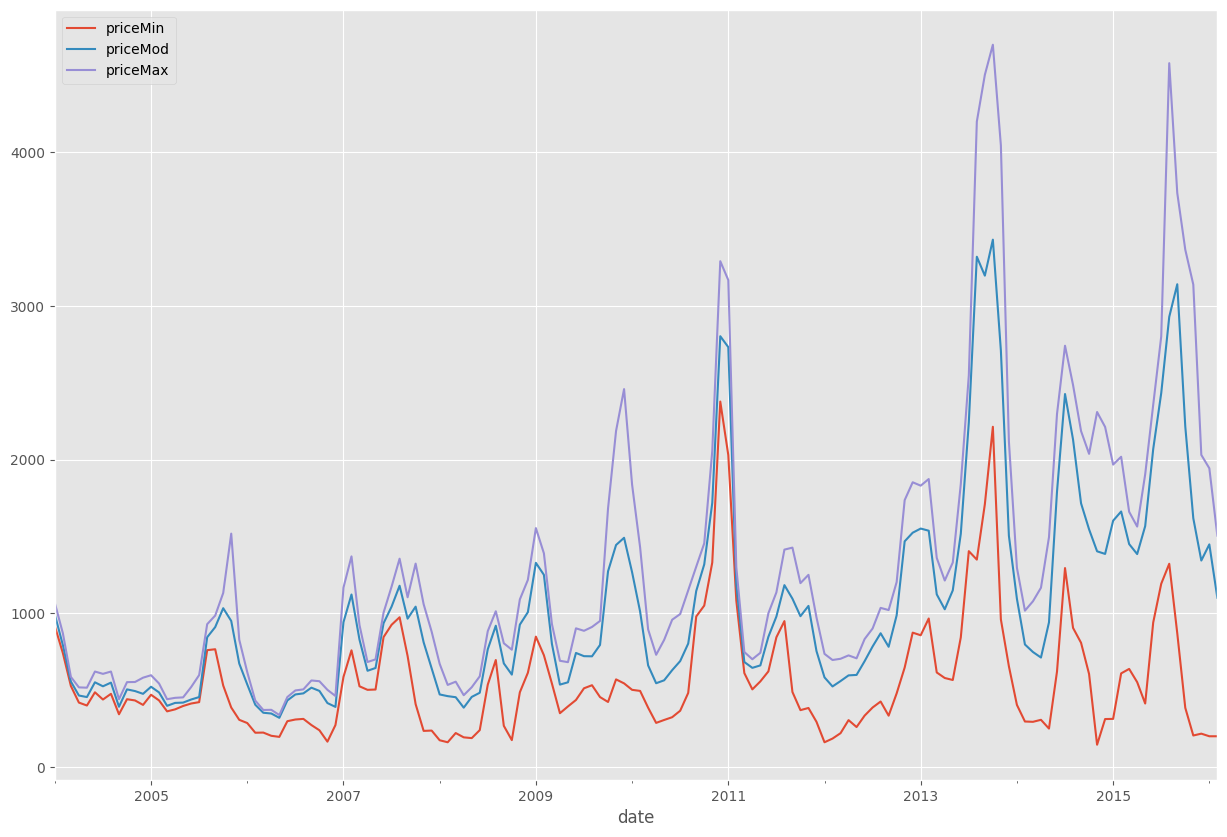

In [10]:
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (15, 10)
dfBang.plot(kind = "line", y = ['priceMin', 'priceMod', 'priceMax']);

La variable más estable de las tres graficadas en el plot anterior es el precio modal, así que utilizaremos esa. Sin embargo, no se trata de una seria estacionaria porque se que el valor del precio va aumentando con el tiempo, así que debemos aplciar alguna transformación para convertirla en una serie estacionaria. Veamos lo que pasa si aplicamos una transformación logarítmica a la serie:

In [11]:
# Transformamos a logaritmo para reducir la variablidad de la serie
dfBang['priceModLog'] = np.log(dfBang.priceMod)
dfBang.head()

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date,priceModLog
date,,,,,,,,,,,
2004-01,BANGALORE,January,2004,227832,916,1066,991,KNT,BANGALORE,2004-01-01,6.898715
2004-02,BANGALORE,February,2004,225133,741,870,793,KNT,BANGALORE,2004-02-01,6.675823
2004-03,BANGALORE,March,2004,221952,527,586,556,KNT,BANGALORE,2004-03-01,6.320768
2004-04,BANGALORE,April,2004,185150,419,518,465,KNT,BANGALORE,2004-04-01,6.142037
2004-05,BANGALORE,May,2004,137390,400,516,455,KNT,BANGALORE,2004-05-01,6.120297


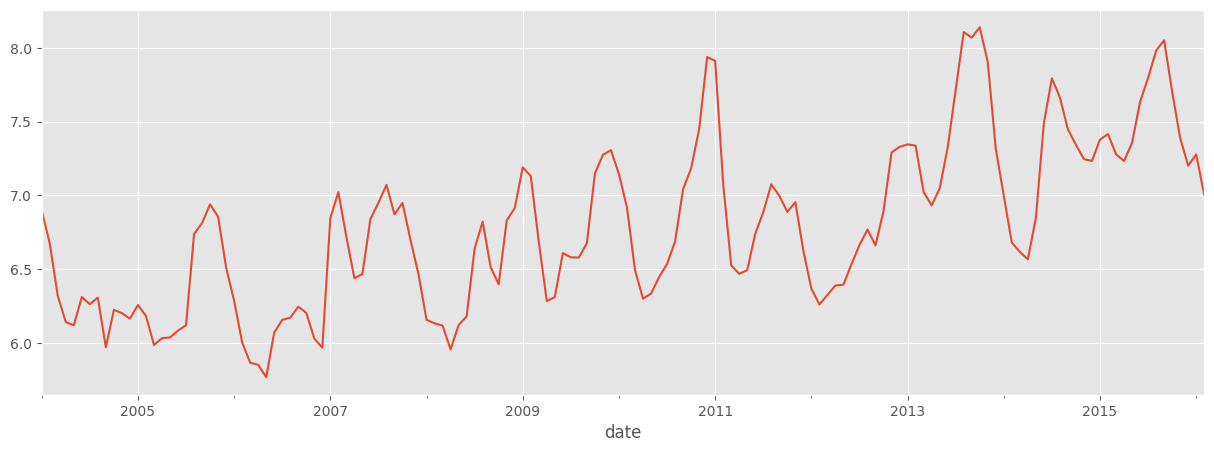

In [12]:
plt.rcParams['figure.figsize'] = (15, 5)
dfBang.priceModLog.plot();

Como la transformación logaritmo no es lineal, observamos que las fluctuaciones son más parecidas entre sí al principio y al final de la serie.

## 2) Modelos básicos para prónosticos
* Modelo de la media constante
* Modelo de tendencia lineal
* Modelo Random Walk


La serie que vamos a intentar predecir con los siguientes modelos es la moda del precio mensual de la cebolla en el mercado de Bangalore.

## 2.a) Media constante

In [13]:
# Calculamos el promedio, uniforme para todos
model_mean_pred = dfBang.priceModLog.mean()

# Transformamos ese volor, inicialmente calculado en logaritmo
# Lo asignamos a una columna
dfBang["priceMean"] = np.exp(model_mean_pred)

dfBang["priceMean"].head()

,priceMean
date,
2004-01,884.565812
2004-02,884.565812
2004-03,884.565812
2004-04,884.565812
2004-05,884.565812


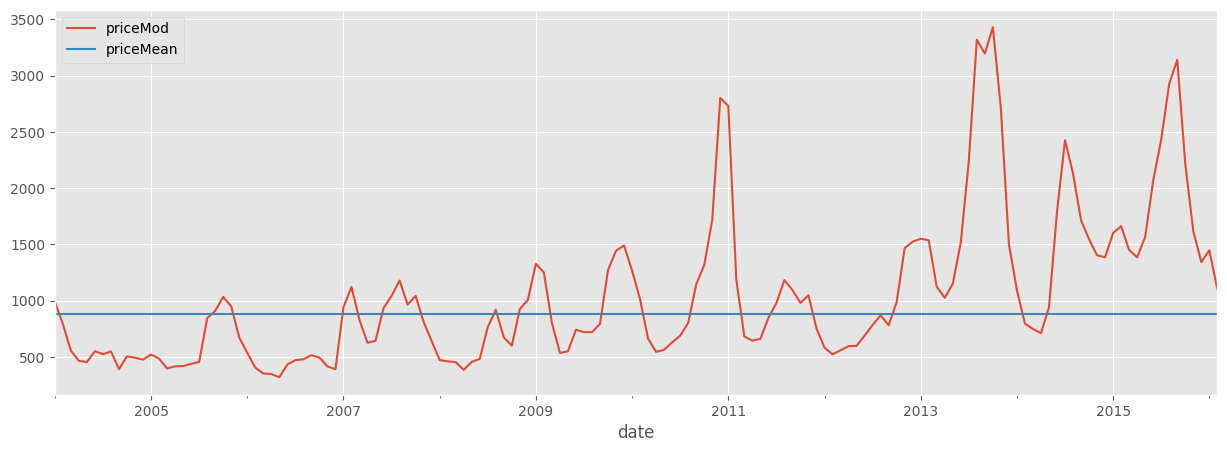

In [14]:
# Ploteamos los valores originales
dfBang.plot(kind="line", x="date", y = ["priceMod", "priceMean"]);

* ¿Cuán bien ajusta esta estimación?

Calculemos el Error Cuadrático Medio y su raíz...

In [15]:
def RMSE(predicted, actual):
    mse = (predicted - actual)**2
    rmse = np.sqrt(mse.sum()/mse.count())
    return rmse

In [16]:
model_mean_RMSE = RMSE(dfBang.priceMean, dfBang.priceMod)
model_mean_RMSE

683.9533483996255

In [17]:
# Guardamos todo en un dataframe
dfBangResults = pd.DataFrame(columns = ["Model", "Forecast", "RMSE"])
dfBangResults.loc[0,"Model"] = "Mean"
dfBangResults.loc[0,"Forecast"] = np.exp(model_mean_pred)
dfBangResults.loc[0,"RMSE"] = model_mean_RMSE
dfBangResults.head()

,Model,Forecast,RMSE
0,Mean,884.565812,683.953348


* ¿Cómo interpretás este resultado?

## 2.b) Tendencia lineal

Continuaremos trabajando con la tendencia lineal entre priceModLog y time. Primero tenemos que crear un  indicador numérico para el período de tiempo para hacer una regresión lineal.

In [18]:
# Rotomamos el subset de Bangalore
# Identificamos el punto de inicio de la data
dfBang.date.min()

Timestamp('2004-01-01 00:00:00')

In [19]:
# Convertimos nuestra data almacenada en 'date' en datetime-delta, comenzando por cero
dfBang["timeIndex"] = dfBang.date - dfBang.date.min()
dfBang.head()

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date,priceModLog,priceMean,timeIndex
date,,,,,,,,,,,,,
2004-01,BANGALORE,January,2004,227832,916,1066,991,KNT,BANGALORE,2004-01-01,6.898715,884.565812,0 days
2004-02,BANGALORE,February,2004,225133,741,870,793,KNT,BANGALORE,2004-02-01,6.675823,884.565812,31 days
2004-03,BANGALORE,March,2004,221952,527,586,556,KNT,BANGALORE,2004-03-01,6.320768,884.565812,60 days
2004-04,BANGALORE,April,2004,185150,419,518,465,KNT,BANGALORE,2004-04-01,6.142037,884.565812,91 days
2004-05,BANGALORE,May,2004,137390,400,516,455,KNT,BANGALORE,2004-05-01,6.120297,884.565812,121 days


In [20]:
# Transformamos la última columna de días a meses con timedelta
dfBang["timeIndex"] =  dfBang["timeIndex"]/np.timedelta64(30, 'D')


In [21]:
# Redondeamos, quitando todos los decimales
dfBang["timeIndex"] = dfBang["timeIndex"].astype(int)
dfBang.timeIndex.head(), type(dfBang.timeIndex)

(date
 2004-01    0
 2004-02    1
 2004-03    2
 2004-04    3
 2004-05    4
 Freq: M, Name: timeIndex, dtype: int64,
 pandas.core.series.Series)

In [22]:
dfBang.timeIndex.tail()

,timeIndex
date,
2015-10,143
2015-11,144
2015-12,145
2016-01,146
2016-02,147


In [23]:
dfBang.head()

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date,priceModLog,priceMean,timeIndex
date,,,,,,,,,,,,,
2004-01,BANGALORE,January,2004,227832,916,1066,991,KNT,BANGALORE,2004-01-01,6.898715,884.565812,0
2004-02,BANGALORE,February,2004,225133,741,870,793,KNT,BANGALORE,2004-02-01,6.675823,884.565812,1
2004-03,BANGALORE,March,2004,221952,527,586,556,KNT,BANGALORE,2004-03-01,6.320768,884.565812,2
2004-04,BANGALORE,April,2004,185150,419,518,465,KNT,BANGALORE,2004-04-01,6.142037,884.565812,3
2004-05,BANGALORE,May,2004,137390,400,516,455,KNT,BANGALORE,2004-05-01,6.120297,884.565812,4


In [24]:
# Ahora fiteamos nuestro modelo de regresión lineal entre priceMod y timeIndex
# ols: ordinary least squares, modelo de regresion lineal de statsmodel en ves de usar de scikit-learn
model_linear = smf.ols('priceModLog ~ timeIndex', data = dfBang).fit()

El primer argumento corresponde a la forma funcional de nuestra estimación. [Más detalles](http://www.statsmodels.org/dev/examples/notebooks/generated/formulas.html).

In [25]:
model_linear.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            priceModLog   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                     140.0
Date:                Fri, 28 Feb 2025   Prob (F-statistic):           5.43e-23
Time:                        17:05:53   Log-Likelihood:                -72.258
No. Observations:                 146   AIC:                             148.5
Df Residuals:                     144   BIC:                             154.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.1146      0.066     93.187      0.000       5.985       6.244
timeIndex      0.0092      0.001     11.833      0.000       0.008       0.011
==============================================================================
Omnibus:                        4.732   Durbin-Watson:                   0.384
Prob(Omnibus):                  0.094   Jarque-Bera (JB):                4.713
Skew:                           0.403   Prob(JB):                       0.0947
Kurtosis:                       2.644   Cond. No.                         168.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
model_linear_pred = model_linear.predict()
model_linear_pred[:5]

array([6.11455151, 6.12372673, 6.13290195, 6.14207717, 6.1512524 ])

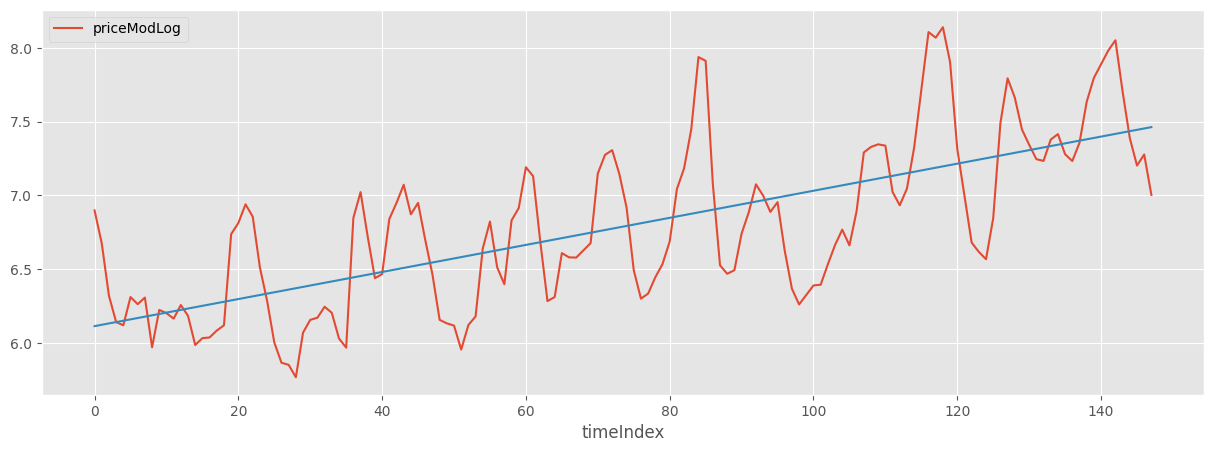

In [27]:
# Ploteamos los resultados de la predicción
dfBang.plot(kind="line", x="timeIndex", y = "priceModLog")
plt.plot(dfBang.timeIndex,model_linear_pred, '-');

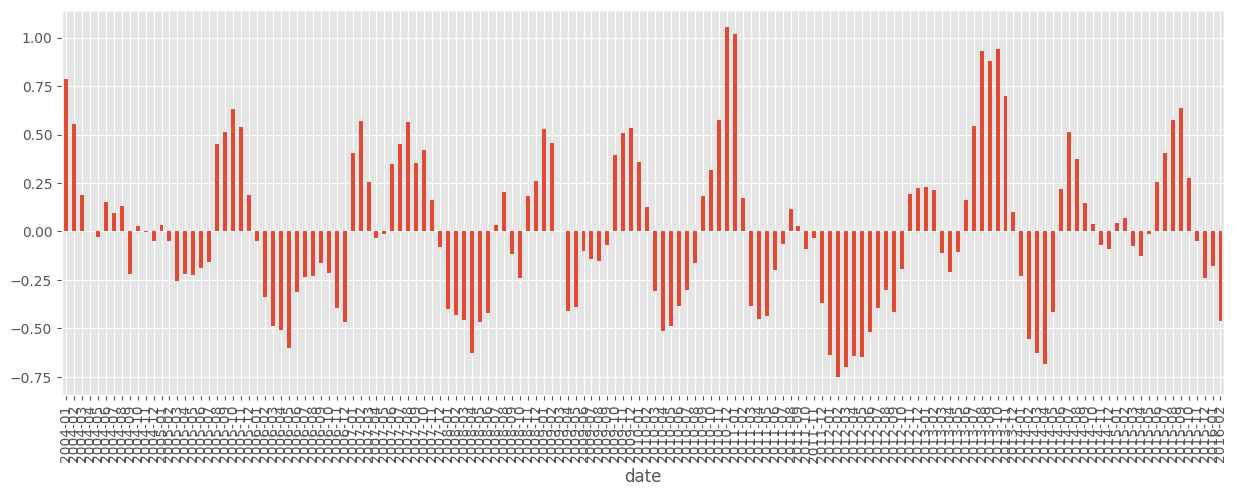

In [28]:
# Ploteamos los residuos de nuestra estimación
model_linear.resid.plot(kind = "bar");

* ¿Tenemos un mejor modelo respecto de la media constante? ¿Cómo podemos verificarlo?

En ambos gráficos vemos que el modelo de tendencia lineal es propenso a cometer un error del mismo signo durante varios períodos seguidos. Este sesgo del modelo se mide en términos estadísticos mediante la **autocorrelación lag-1** (se denomina así a la correlación de una variable respecto a sí misma rezagada un período de tiempo) a través del estadístico **Durbin-Watson**. Si no hay un patrón de tiempo, la autocorrelación lag-1 debería ser muy cercana a cero (veamos el cuadro resumen del modelo más arriba) y, por lo tanto, la estadística de Durbin-Watson debería ser  muy cercana a 2 (no es este caso). Si el modelo ha logrado extraer toda la "señal" de los datos, no debería haber ningún patrón en los errores, es decir, el error del período siguiente no debería estar correlacionado con ningún error anterior como observamos aquí. El modelo de tendencia lineal suele fallar cuando se testea la autocorrelación.


En palabras más sencillas, lo que se dice en este texto es que el modelo de tendencia lineal tiende a cometer errores similares (del mismo tipo) durante varios periodos seguidos. Este tipo de error se puede medir con una herramienta estadística llamada autocorrelación lag-1, que básicamente mide si el error de un periodo está relacionado con el error del periodo anterior.

Si el modelo estuviera haciendo un buen trabajo, los errores no deberían seguir ningún patrón en el tiempo. En otras palabras, el error de un periodo no debería estar relacionado con los errores anteriores. Cuando no hay ningún patrón, la autocorrelación lag-1 debería ser cercana a cero, y una estadística llamada Durbin-Watson debería ser cercana a 2.

Sin embargo, en este caso, no se cumple ese patrón, lo que sugiere que el modelo de tendencia lineal no está funcionando bien y comete errores consecutivos que están relacionados entre sí. Por lo tanto, el modelo de tendencia lineal suele fallar cuando se verifica la autocorrelación de los errores.

In [29]:
dfBang["priceLinear"] = np.exp(model_linear_pred)
dfBang.head()

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date,priceModLog,priceMean,timeIndex,priceLinear
date,,,,,,,,,,,,,,
2004-01,BANGALORE,January,2004,227832,916,1066,991,KNT,BANGALORE,2004-01-01,6.898715,884.565812,0,452.393106
2004-02,BANGALORE,February,2004,225133,741,870,793,KNT,BANGALORE,2004-02-01,6.675823,884.565812,1,456.563014
2004-03,BANGALORE,March,2004,221952,527,586,556,KNT,BANGALORE,2004-03-01,6.320768,884.565812,2,460.771359
2004-04,BANGALORE,April,2004,185150,419,518,465,KNT,BANGALORE,2004-04-01,6.142037,884.565812,3,465.018493
2004-05,BANGALORE,May,2004,137390,400,516,455,KNT,BANGALORE,2004-05-01,6.120297,884.565812,4,469.304775


In [30]:
# Root Mean Squared Error (RMSE)
model_linear_RMSE = RMSE(dfBang.priceLinear, dfBang.priceMod)
model_linear_RMSE

518.3582289790639

In [31]:
# Añadimos estos datos a nuestro DF de resultados para comparar con el modelo anterior
dfBangResults.loc[1,"Model"] = "Linear"
dfBangResults.loc[1,"Forecast"] = np.exp(model_linear_pred)
dfBangResults.loc[1,"RMSE"] = model_linear_RMSE
dfBangResults.head()

,Model,Forecast,RMSE
0,Mean,884.565812,683.953348
1,Linear,"[452.39310614946214, 456.5630144738825, 460.77...",518.358229


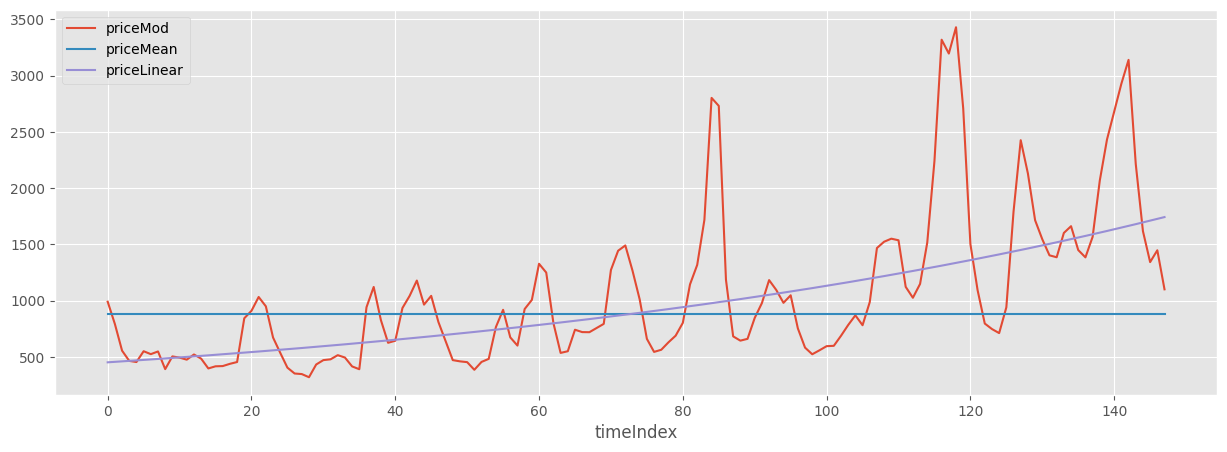

In [32]:
# Ploteamos las dos estimaciones
dfBang.plot(kind="line", x="timeIndex", y = ["priceMod", "priceMean", "priceLinear"]);

### Tendencia lineal con un regresor

Ahora vamos a explorar un modelo lineal que permite tener en cuenta la cantidad.
Cuando incluimos un feature adicional (además del tiempo) en una serie de tiempo existen dos posibilidades:
1. El regresor se conoce a la hora de pronosticar: por ejemplo la ubicación donde la empresa estará en un momento del tiempo, que ya puede estar planificada.
2. El regresor no se conoce a la hora de pronosticar: por ejemplo la cantidad en este caso

Cuando nos encontramos en el segundo escenario, tenemos que tener en cuenta que el modelo de serie de tiempo va a ser útil para entender las relaciones entre las variables recurriendo al pasado (es decir, para modelar) pero no para hacer pronósticos a futuro.


In [33]:
# Ahora estimamos una variante del modelo lineal, incluyendo el logaritmo de las cantidades como regresor
model_linear_quantity = smf.ols('priceModLog ~ timeIndex + np.log(quantity)', data = dfBang).fit()
model_linear_quantity.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            priceModLog   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     74.26
Date:                Fri, 28 Feb 2025   Prob (F-statistic):           7.64e-23
Time:                        17:12:43   Log-Likelihood:                -69.845
No. Observations:                 146   AIC:                             145.7
Df Residuals:                     143   BIC:                             154.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.1887      0.881      4.755      0.000       2.447       5.930
timeIndex            0.0083      0.001      9.782      0.000       0.007       0.010
np.log(quantity)     0.1525      0.070      2.192      0.030       0.015       0.290
==============================================================================
Omnibus:                        5.105   Durbin-Watson:                   0.412
Prob(Omnibus):                  0.078   Jarque-Bera (JB):                4.947
Skew:                           0.401   Prob(JB):                       0.0843
Kurtosis:                       2.589   Cond. No.                     2.31e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.31e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [34]:
dfBang["priceLinearQuantity"] = np.exp(model_linear_quantity.predict())

In [35]:
model_linear_quantity.params

,0
Intercept,4.188725
timeIndex,0.008348
np.log(quantity),0.152452


In [38]:
dfBang.iloc[dfBang.shape[0] - 2, :]

,2016-01
market,BANGALORE
month,January
year,2016
quantity,507223
priceMin,200
priceMax,1943
priceMod,1448
state,KNT
city,BANGALORE
date,2016-01-01 00:00:00


In [36]:
# Calculamos el RMSE y lo añadimos al DF de resultados
dfBangResults.loc[2,"Model"] = "LinearQuantity"
dfBangResults.loc[2,"Forecast"] = np.exp(model_linear_quantity.params[0] +
                                        model_linear_quantity.params[1] * 146 +
                                        model_linear_quantity.params[2] * np.log(4000000))
dfBangResults.loc[2,"RMSE"] = RMSE(dfBang.priceLinearQuantity, dfBang.priceMod)
dfBangResults.head()

<ipython-input-36-6590c1e650d8>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dfBangResults.loc[2,"Forecast"] = np.exp(model_linear_quantity.params[0] +
<ipython-input-36-6590c1e650d8>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_linear_quantity.params[1] * 146 +
<ipython-input-36-6590c1e650d8>:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_linear_quantity.params[2] * np.log(4000000))


,Model,Forecast,RMSE
0,Mean,884.565812,683.953348
1,Linear,"[452.39310614946214, 456.5630144738825, 460.77...",518.358229
2,LinearQuantity,2264.30834,505.131419


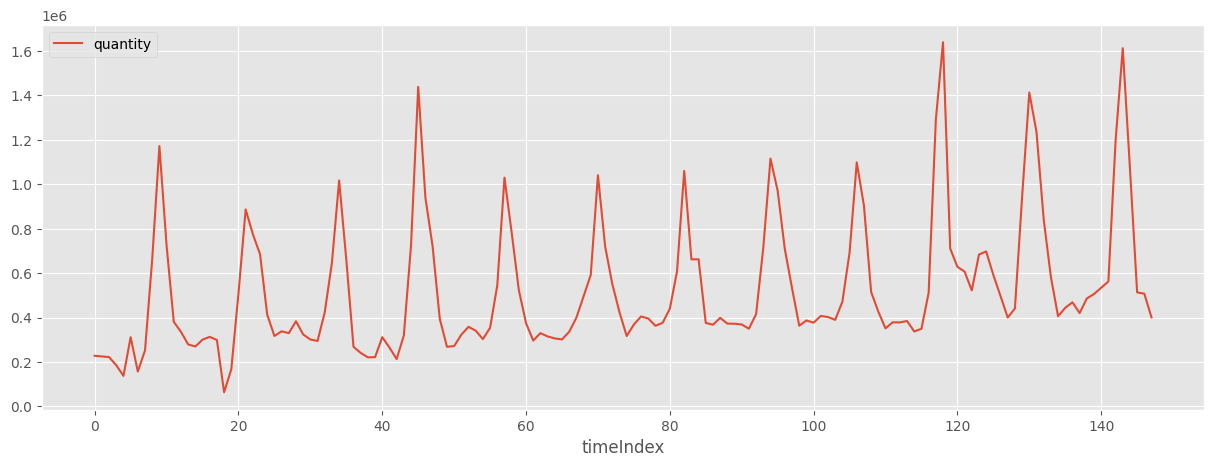

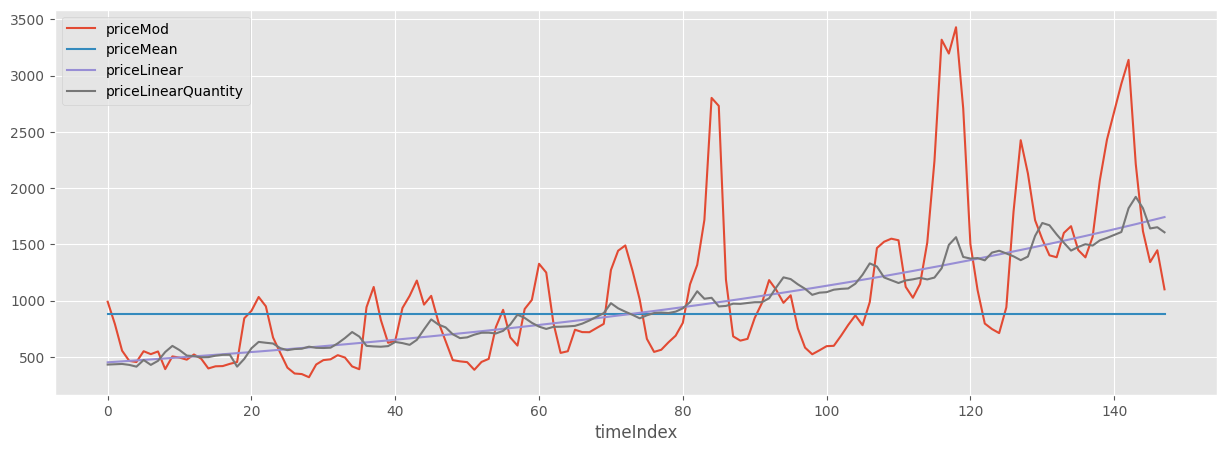

In [39]:
dfBang.plot(kind = "line", x="timeIndex", y = "quantity")
dfBang.plot(kind="line", x="timeIndex", y = ["priceMod", "priceMean",
                                             "priceLinear", "priceLinearQuantity"]);

Obsrvamos que al usar la cantidad para modelar el precio el modelo puede dar mejor cuenta de las fluctuaciones.

## 2.c) Random Walk

Cuando nos enfrentamos a una serie de tiempo que muestra crecimiento irregular, la mejor estrategia no es tratar de predecir directamente el nivel de la serie en cada período (es decir, el valor Yt), sino el cambio que ocurre de un período al siguiente (es decir, la diferencia Yt - Yt-1). Se observa la primera diferencia (o lag) de la serie para encontrar un patrón predecible.

A los efectos del pronóstico del próximo período, puede ser tan bueno predecir el nivel como la variación, ya que el cambio predicho puede agregarse al nivel actual para generar un nivel pronosticado. El caso más simple de dicho modelo es uno que siempre predice que el siguiente cambio será cero, como si la serie tuviera la misma probabilidad de subir o bajar en el próximo período, independientemente de lo que haya sucedido en el pasado.

**Random Walk** $$ \ hat {Y_t} = Y_ {t-1} + \ epsilon \\ $$

**Random Walk with drift (derivada)** $$ \ hat {Y_t} = Y_ {t-1} + c + \ epsilon \\ $$

### ¿Qué es un Random Walk en Series de Tiempo y Pronósticos?

En el contexto de **series de tiempo** y **pronósticos**, un **random walk** es un modelo que se utiliza para describir una serie temporal donde cada valor futuro de la serie depende únicamente del valor actual más un componente aleatorio (o ruido), y no de ninguna tendencia o patrón predecible a largo plazo. Este modelo es una forma simple de modelar series temporales en las que el futuro es incierto y sigue un comportamiento impredecible.

### Explicación para Series de Tiempo:

En una serie de tiempo con un **random walk**, el siguiente valor se calcula como:

$$ X_{t+1} = X_t + \epsilon_t $$

- $X_{t+1}$ es el valor de la serie en el siguiente periodo de tiempo.
- $X_t$ es el valor en el periodo actual.
- $\epsilon_t$ es un error aleatorio (ruido) en ese periodo, generalmente distribuido de forma normal con media 0 y una cierta varianza.

Es decir, el modelo de **random walk** se basa en la suposición de que el valor futuro de la serie es el valor presente más un "shock" o cambio aleatorio, sin ninguna tendencia subyacente predecible.

### Características de un Random Walk en Series de Tiempo:

1. **Dependencia solo en el valor anterior**:
   El valor futuro de la serie solo depende del valor presente y de un componente aleatorio (ruido). No hay dependencia de valores pasados adicionales. Esto significa que la serie no tiene memoria de largo plazo.

2. **Sin tendencia definida**:
   Un random walk no tiene tendencia o patrón sistemático. Los valores en la serie pueden subir o bajar aleatoriamente, y no siguen una tendencia clara hacia arriba o hacia abajo.

3. **Comportamiento impredecible**:
   Debido a que la serie está dominada por componentes aleatorios, es difícil predecir los valores futuros de la serie a largo plazo, ya que las fluctuaciones son completamente aleatorias.

### Pronósticos con Random Walk:

Cuando se utiliza un **random walk** para pronósticos de series de tiempo, la idea es que el pronóstico del siguiente valor es igual al valor actual de la serie, más un error aleatorio (en otras palabras, no hay un cambio sistemático esperado, solo fluctuaciones aleatorias).

El pronóstico para el siguiente valor $X_{t+1}$ es simplemente:

$$ \hat{X}_{t+1} = X_t $$

Donde:

- $\hat{X}_{t+1}$ es la predicción para el siguiente periodo.
- $X_t$ es el valor observado en el periodo actual.

### Propiedades de los Modelos Random Walk en Series de Tiempo:

1. **No es estacionario**:
   Un random walk no es una serie estacionaria porque su media y varianza no son constantes a lo largo del tiempo. La varianza crece con el tiempo, lo que significa que los valores se dispersan más a medida que avanza el tiempo.

2. **Autocorrelación alta**:
   Un random walk tiene autocorrelación significativa en los primeros rezagos (especialmente el rezago 1). Esto significa que los valores futuros están muy correlacionados con los valores pasados inmediatos, pero no necesariamente con los valores más lejanos.

3. **Modelo "simple"**:
   Aunque el random walk es un modelo muy simple, a menudo se usa como un punto de referencia en la predicción de series temporales, especialmente cuando se comparan otros modelos más complejos. Si un modelo complejo no mejora significativamente el pronóstico con respecto a un random walk, puede indicar que el modelo no está capturando patrones útiles.

### Ejemplo de Pronóstico con Random Walk:

Imagina que tienes una serie temporal de precios de una acción en el tiempo. Supongamos que el último precio observado es 100. Según el modelo de random walk, el pronóstico para el próximo periodo sería simplemente ese mismo valor (100), ya que el modelo no supone una tendencia o patrón, sino que el próximo valor se deriva del valor actual más un error aleatorio.

Si observas la serie de tiempo a lo largo de muchos periodos, verás que los valores se mueven de forma errática, subiendo y bajando sin una tendencia clara, lo que refleja la naturaleza aleatoria del modelo.

### Limitaciones del Random Walk para Pronósticos:

- **No predice tendencias**: Como no hay un patrón o tendencia en el modelo, no puedes usar un random walk para prever aumentos o disminuciones sostenidas en una serie temporal.
- **No captura patrones complejos**: Si hay patrones cíclicos o estacionales en los datos, un random walk no los identificará ni los aprovechará.

### Resumen:

En el contexto de series de tiempo y pronósticos, un **random walk** es un modelo simple donde el valor futuro de la serie es igual al valor actual más un error aleatorio. Este modelo no tiene tendencia y se utiliza principalmente para describir series temporales impredecibles. El principal pronóstico de un random walk es que el valor futuro será igual al valor presente, lo que lo convierte en un modelo de referencia sencillo para evaluar la calidad de otros modelos más complejos.


In [40]:
# Generamos el desplazamiento de nuestro nuestro target (lag=1)
dfBang["priceModLogShift1"] = dfBang.priceModLog.shift()
dfBang.head()

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date,priceModLog,priceMean,timeIndex,priceLinear,priceLinearQuantity,priceModLogShift1
date,,,,,,,,,,,,,,,,
2004-01,BANGALORE,January,2004,227832,916,1066,991,KNT,BANGALORE,2004-01-01,6.898715,884.565812,0,452.393106,432.431267,NaN
2004-02,BANGALORE,February,2004,225133,741,870,793,KNT,BANGALORE,2004-02-01,6.675823,884.565812,1,456.563014,435.264665,6.898715
2004-03,BANGALORE,March,2004,221952,527,586,556,KNT,BANGALORE,2004-03-01,6.320768,884.565812,2,460.771359,437.962166,6.675823
2004-04,BANGALORE,April,2004,185150,419,518,465,KNT,BANGALORE,2004-04-01,6.142037,884.565812,3,465.018493,429.594399,6.320768
2004-05,BANGALORE,May,2004,137390,400,516,455,KNT,BANGALORE,2004-05-01,6.120297,884.565812,4,469.304775,413.933918,6.142037


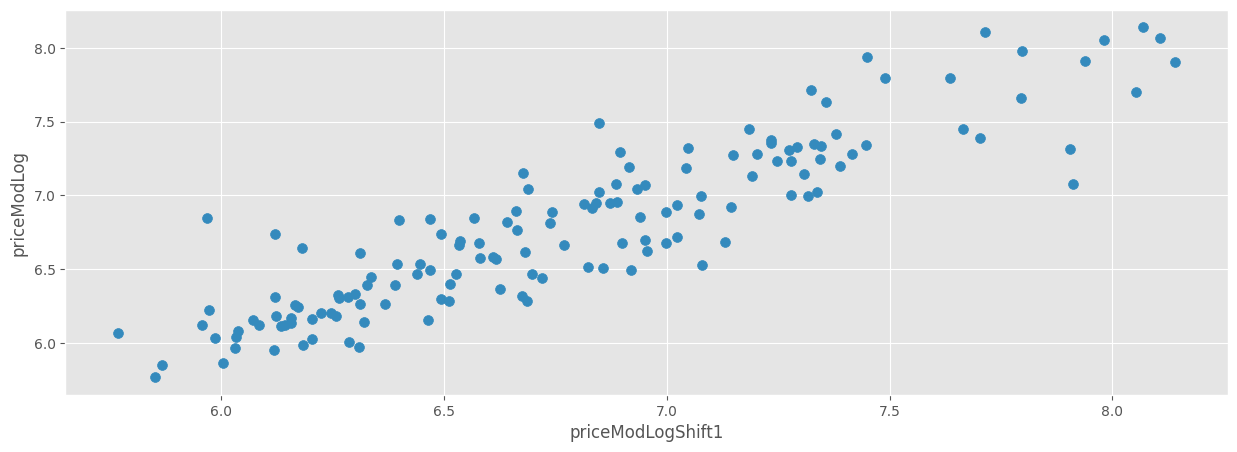

In [41]:
dfBang.plot(kind= "scatter", y = "priceModLog", x = "priceModLogShift1", s = 50);

In [43]:
dfBang[["priceModLog", "priceModLogShift1"]].corr()

,priceModLog,priceModLogShift1
priceModLog,1.000000,0.902598
priceModLogShift1,0.902598,1.000000


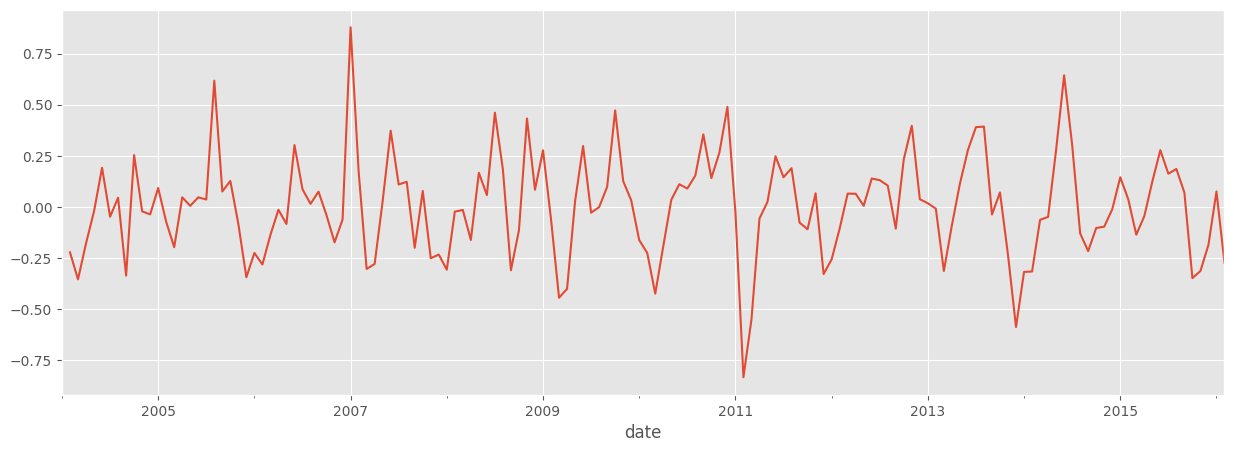

In [44]:
# Ploteamos la relación entre nuestro target y el lag de un período
dfBang["priceModLogDiff"] = dfBang.priceModLog - dfBang.priceModLogShift1
dfBang.priceModLogDiff.plot();

In [45]:
dfBang["priceRandom"] = np.exp(dfBang.priceModLogShift1)
dfBang.tail()

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date,priceModLog,priceMean,timeIndex,priceLinear,priceLinearQuantity,priceModLogShift1,priceModLogDiff,priceRandom
date,,,,,,,,,,,,,,,,,,
2015-10,BANGALORE,October,2015,1612160,385,3365,2215,KNT,BANGALORE,2015-10-01,7.703008,884.565812,143,1680.099678,1922.623312,8.051978,-0.348970,3140.0
2015-11,BANGALORE,November,2015,1071872,205,3138,1618,KNT,BANGALORE,2015-11-01,7.388946,884.565812,144,1695.585904,1821.776853,7.703008,-0.314062,2215.0
2015-12,BANGALORE,December,2015,513186,217,2030,1343,KNT,BANGALORE,2015-12-01,7.202661,884.565812,145,1711.214873,1641.935562,7.388946,-0.186285,1618.0
2016-01,BANGALORE,January,2016,507223,200,1943,1448,KNT,BANGALORE,2016-01-01,7.277939,884.565812,146,1726.987901,1652.751779,7.202661,0.075277,1343.0
2016-02,BANGALORE,February,2016,400359,200,1505,1101,KNT,BANGALORE,2016-02-01,7.003974,884.565812,147,1742.906316,1607.565495,7.277939,-0.273964,1448.0


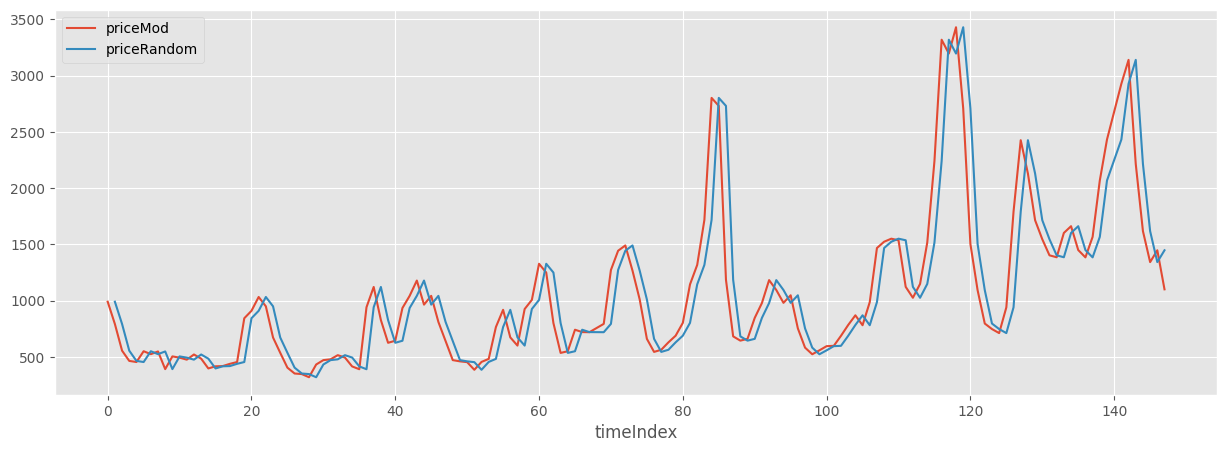

In [ ]:
dfBang.plot(kind="line", x="timeIndex", y = ["priceMod","priceRandom"]);

In [46]:
# Calculamos el RMSE y almacenamos los resultados
dfBangResults.loc[3,"Model"] = "Random"
dfBangResults.loc[3,"Forecast"] = np.exp(dfBang.priceModLogShift1[-1])
dfBangResults.loc[3,"RMSE"] = RMSE(dfBang.priceRandom, dfBang.priceMod)
dfBangResults.head()

<ipython-input-46-c99b00ba3497>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dfBangResults.loc[3,"Forecast"] = np.exp(dfBang.priceModLogShift1[-1])


,Model,Forecast,RMSE
0,Mean,884.565812,683.953348
1,Linear,"[452.39310614946214, 456.5630144738825, 460.77...",518.358229
2,LinearQuantity,2264.30834,505.131419
3,Random,1448.0,323.5924


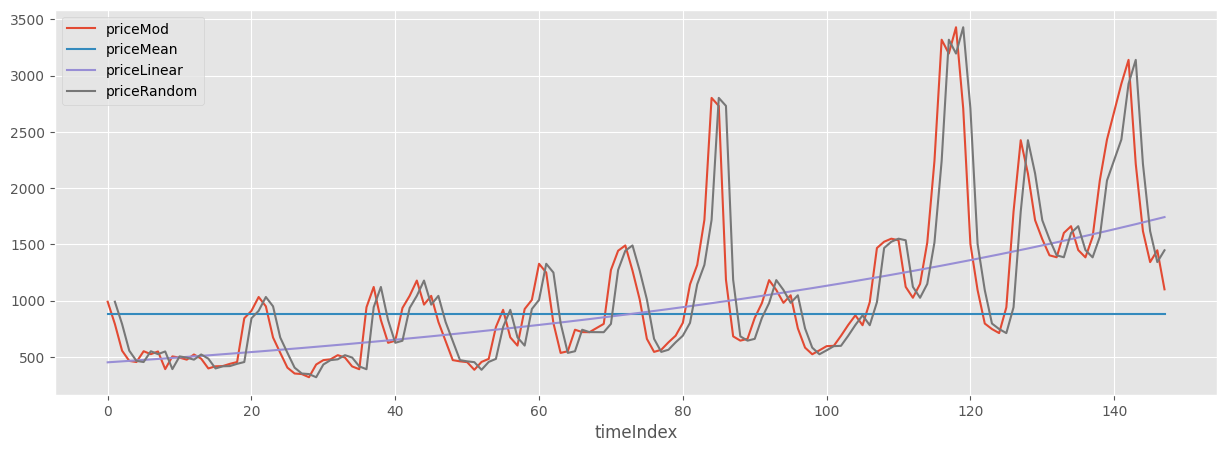

In [47]:
dfBang.plot(kind="line", x="timeIndex", y = ["priceMod", "priceMean", "priceLinear", "priceRandom"]);

## BASE para el ANÁLISIS de las SERIES de TIEMPO

La mayoría de los modelos de series de tiempo funcionan bajo el supuesto de que la serie temporal es estacionaria. Intuitivamente, podemos ver que si una serie de tiempo tiene un comportamiento particular a lo largo del tiempo, existe una gran probabilidad de que siga igual en el futuro. Además, las herramientas relacionadas con series estacionarias han sido más desarrolladas y son más fáciles de implementar que aquellas relacionadas con series que no lo son.

Los models AR y MA requieren para funcionar que la serie sea estacional. La evolución de estos dos modelos, ARIMA, a diferencia de éstos puede trabajar con series no estacionales.


**Estacionariedad estadística:** una serie temporal estacionaria es aquella cuyas propiedades estadísticas tales como media, varianza, autocorrelación, etc. son todas constantes a lo largo del tiempo. La mayoría de los métodos de pronóstico estadístico se basan en la suposición de que las series de tiempo pueden ser representadas como estacionarias (es decir, "desestacionalizadas") mediante el uso de transformaciones matemáticas. Una serie estacionaria es relativamente fácil de predecir: ¡simplemente predice que sus propiedades estadísticas serán las mismas en el futuro que en el pasado!

Hay tres criterios básicos para que una serie se clasifique como serie estacionaria:

- La <strong> media </strong> de la serie no debe ser una función del tiempo sino una constante.
<center><img src='https://image.ibb.co/edfijG/Mean_nonstationary.png'></center>

- La <strong>  varianza </strong> de la serie no debe ser una función del tiempo. Esta propiedad se conoce como homocedasticidad y representa que la serie tiene varianza homogénea a lo largo del tiempo.
<center><img src='https://image.ibb.co/n1kurw/Var_nonstationary.png'></center>

- La <strong> covarianza </strong>  del primer término y el término (i + m) no deberían ser una función del tiempo.  
<center><img src='https://image.ibb.co/hNCw4G/Cov_nonstationary.png'></center>

### ¿Cómo hacemos para que una serie de tiempo sea estacionaria?
Hay 3 componentes centrales vinculados con la **no estacionariedad** de la serie de tiempo:
* **Tendencia (T)**: existe una tendencia cuando hay un aumento o una disminución del nivel (de la variable en cuestión) a largo plazo. No tiene que ser lineal. A veces nos referiremos a un cambio en la dirección (punto de inflexión) de la serie cuando la tendencia pasa de ser creciente a decreciente.
* **Estacionalidad (S por seasonality)**: existe un patrón estacional cuando una serie está influenciada por factores estacionales (por ejemplo, el trimestre del año en lo que refiere a vacaciones o zafra; el mes si contemplamos crecimiento de ventas (ligado a Navidad, por ejemplo) o el día de la semana). La estacionalidad es siempre de un período fijo y conocido.
* **Cíclico**: existe un patrón cíclico cuando los datos exhibidos suben y bajan sin respetar el período fijo ligado a la estacionalidad. La duración de estas fluctuaciones suele ser de al menos 2 años. Si estuviésemos analizando el PBI de un país, los ciclos económicos con años de crecimiento seguidos de otros de recesión constituyen un buen ejemplo. Sin embargo, cuando hay poca información o las variaciones cíclicas no son muy pronunciadas, este componente puede quedar subsumido al de la tendencia.

Podemos describir el comportamiento de la serie a partir de un modelo **aditivo**:
$$ y_t = T_t + S_t + E_t \\ $$
donde $ y_t $ son los datos en el período t, $ T_t $ es el componente del ciclo de tendencia en el período 't', $ S_t $ es el componente estacional en el período 't' y $ E_t $ es el componente restante (o irregular o error) en el período 't'.

Alternativamente, un modelo **multiplicativo** se escribiría como

$$ y_t = T_t * S_t * E_t \\ $$
El modelo aditivo es más apropiado si la magnitud de las fluctuaciones estacionales o la variación en torno al ciclo de tendencia no varía con el nivel de la serie temporal. Cuando la variación en el patrón estacional, o la variación alrededor del ciclo de tendencia, parece ser proporcional al nivel de la serie temporal, entonces un modelo multiplicativo es más apropiado. Con series de tiempo económicas, los modelos multiplicativos son comunes.

Una alternativa al uso de un modelo multiplicativo es transformar primero los datos hasta que la variación en la serie parezca estable a lo largo del tiempo y luego usar un modelo aditivo. Cuando se ha utilizado una transformación de registro, como por ejemplo el pasaje a escala logarítmica, esto es equivalente a usar una descomposición multiplicativa por las propiedades de esta transformación:

$$ log y_t = log T_t + log S_t + log E_t \\ $$

# Aplicación del Logaritmo para Convertir una Serie Temporal en Estacionaria

Aplicar el logaritmo a una serie temporal es una técnica común para estabilizar la varianza y ayudar a convertir una serie no estacionaria en estacionaria. El **trasfondo matemático y estadístico** detrás de esto se basa en los siguientes aspectos:

## 1. Reducción de Heterocedasticidad (Varianza No Constante)
- Muchas series temporales presentan varianza creciente a lo largo del tiempo, lo que se conoce como **heterocedasticidad**. Esto es común en datos financieros o económicos.
- La transformación logarítmica estabiliza la varianza al reducir la magnitud de los valores más grandes en relación con los más pequeños.

**Ejemplo:**  
Si una serie tiene un crecimiento exponencial:

$$ Y_t = e^{X_t} $$

Aplicando logaritmo:

$$ \log(Y_t) = X_t $$

obtenemos una serie que crece de manera **aditiva** en lugar de multiplicativa, reduciendo la varianza.

---

## 2. Conversión de Crecimiento Exponencial a Lineal
- Muchas series económicas y financieras tienen **tendencias exponenciales**. Aplicando logaritmo, la tendencia se vuelve aproximadamente lineal, facilitando su modelado.

**Ejemplo:**  
Supón que el PIB de un país sigue un crecimiento exponencial:

$$ PIB_t = PIB_0 e^{rt} $$

Aplicando logaritmo:

$$ \log(PIB_t) = \log(PIB_0) + r t $$

obtenemos una relación **lineal** en lugar de exponencial.

---

## 3. Transformación de Modelos Multiplicativos a Aditivos
- Muchas series temporales pueden descomponerse en tendencia, estacionalidad y ruido. A veces, estas componentes interactúan de manera **multiplicativa**:

$$ Y_t = T_t \times S_t \times E_t $$

- Aplicando logaritmo, el modelo se transforma en una relación **aditiva**:

$$ \log(Y_t) = \log(T_t) + \log(S_t) + \log(E_t) $$

Esto facilita el análisis y la modelización.

---

## 4. Mejor Aproximación a una Distribución Normal
- Muchas técnicas estadísticas (como modelos ARIMA) asumen que los residuos siguen una distribución normal.
- Aplicar logaritmo ayuda a que la distribución de la serie se acerque más a la normalidad, especialmente si la serie tiene valores sesgados positivamente.

---

## Conclusión
Aplicar el logaritmo es una transformación útil en series temporales porque:

✅ Reduce la varianza heterogénea (heterocedasticidad).  
✅ Convierte tendencias exponenciales en lineales.  
✅ Transforma modelos multiplicativos en aditivos.  
✅ Ayuda a que los datos se aproximen a una distribución normal.  

Después de aplicar logaritmo, a menudo se realizan otras transformaciones como **diferenciación** para lograr estacionariedad completa.


## 3) Modelos intermedios y avanzados para pronósticos

## 3.a.i) Media móvil (simple moving average) - NO confundir con la MA de ARIMA

Como primer paso para ir más allá de los modelos básicos, podemos emplear un modelo suavizado a partir de la media móvil. El supuesto subyacente reside en que la serie temporal sea localmente estacionaria con una media que varía lentamente.
Por lo tanto, tomamos un promedio móvil (local) para estimar el valor actual de la media y luego lo usamos como pronóstico para el futuro cercano. Esto se puede considerar como un punto medio entre el modelo de media constante y el Random Walk. La misma estrategia se puede usar para estimar y extrapolar una tendencia local. Un promedio móvil a menudo se denomina versión "suavizada" de la serie original porque el promedio a corto plazo tiene el efecto de suavizar los baches en la serie original. Al ajustar el grado de suavización (el ancho de la media móvil o la cantidad de períodos considerados para dicho cálculo), podemos esperar encontrar algún tipo de equilibrio óptimo entre los dos modelos básicos recién mencionados.

$$ \ hat {y_t} = \ frac {y_ {t-1} + y_ {t-2} + y_ {t-3} + ... + y_ {t-m}} {m} \\ $$

In [48]:
# Calculamos la media móvil de 12 meses para suavizar los valores y ploteamos
# dfBang['priceModLogMA12'] =: Crea una nueva columna en el DataFrame llamada priceModLogMA12 y asigna los valores del promedio móvil de 12 periodos calculado en el paso anterior.
dfBang['priceModLogMA12'] = dfBang.priceModLog.rolling(window = 12).mean()
dfBang.head(13)

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date,priceModLog,priceMean,timeIndex,priceLinear,priceLinearQuantity,priceModLogShift1,priceModLogDiff,priceRandom,priceModLogMA12
date,,,,,,,,,,,,,,,,,,,
2004-01,BANGALORE,January,2004,227832,916,1066,991,KNT,BANGALORE,2004-01-01,6.898715,884.565812,0,452.393106,432.431267,NaN,NaN,NaN,NaN
2004-02,BANGALORE,February,2004,225133,741,870,793,KNT,BANGALORE,2004-02-01,6.675823,884.565812,1,456.563014,435.264665,6.898715,-0.222891,991.0,NaN
2004-03,BANGALORE,March,2004,221952,527,586,556,KNT,BANGALORE,2004-03-01,6.320768,884.565812,2,460.771359,437.962166,6.675823,-0.355055,793.0,NaN
2004-04,BANGALORE,April,2004,185150,419,518,465,KNT,BANGALORE,2004-04-01,6.142037,884.565812,3,465.018493,429.594399,6.320768,-0.178731,556.0,NaN
2004-05,BANGALORE,May,2004,137390,400,516,455,KNT,BANGALORE,2004-05-01,6.120297,884.565812,4,469.304775,413.933918,6.142037,-0.021740,465.0,NaN
2004-06,BANGALORE,June,2004,311445,486,621,551,KNT,BANGALORE,2004-06-01,6.311735,884.565812,5,473.630566,472.869903,6.120297,0.191437,455.0,NaN
2004-07,BANGALORE,July,2004,157022,439,606,525,KNT,BANGALORE,2004-07-01,6.263398,884.565812,6,477.996229,429.560881,6.311735,-0.048337,551.0,NaN
2004-08,BANGALORE,August,2004,251984,476,621,549,KNT,BANGALORE,2004-08-01,6.308098,884.565812,7,482.402133,465.549150,6.263398,0.044700,525.0,NaN
2004-09,BANGALORE,September,2004,662382,343,441,392,KNT,BANGALORE,2004-09-01,5.971262,884.565812,8,486.848648,543.976648,6.308098,-0.336837,549.0,NaN


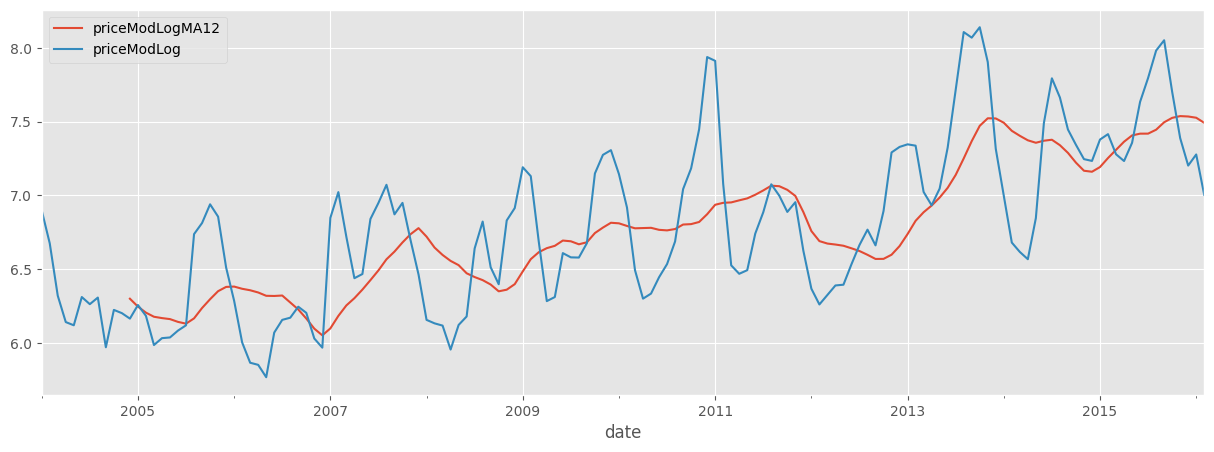

In [49]:
dfBang.plot(kind ="line", y=["priceModLogMA12", "priceModLog"]);

¿Podemos concluir que la media varía a lo largo del tiempo?

In [50]:
dfBang["priceMA12"] = np.exp(dfBang.priceModLogMA12)
dfBang.tail()

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date,priceModLog,priceMean,timeIndex,priceLinear,priceLinearQuantity,priceModLogShift1,priceModLogDiff,priceRandom,priceModLogMA12,priceMA12
date,,,,,,,,,,,,,,,,,,,,
2015-10,BANGALORE,October,2015,1612160,385,3365,2215,KNT,BANGALORE,2015-10-01,7.703008,884.565812,143,1680.099678,1922.623312,8.051978,-0.348970,3140.0,7.526074,1855.805596
2015-11,BANGALORE,November,2015,1071872,205,3138,1618,KNT,BANGALORE,2015-11-01,7.388946,884.565812,144,1695.585904,1821.776853,7.703008,-0.314062,2215.0,7.537956,1877.986866
2015-12,BANGALORE,December,2015,513186,217,2030,1343,KNT,BANGALORE,2015-12-01,7.202661,884.565812,145,1711.214873,1641.935562,7.388946,-0.186285,1618.0,7.535329,1873.061120
2016-01,BANGALORE,January,2016,507223,200,1943,1448,KNT,BANGALORE,2016-01-01,7.277939,884.565812,146,1726.987901,1652.751779,7.202661,0.075277,1343.0,7.526907,1857.351582
2016-02,BANGALORE,February,2016,400359,200,1505,1101,KNT,BANGALORE,2016-02-01,7.003974,884.565812,147,1742.906316,1607.565495,7.277939,-0.273964,1448.0,7.492590,1794.694278


In [51]:
# Incorporamos estimaciones y resultados a nuestro DF
dfBangResults.loc[4,"Model"] = "Moving Average 12"
dfBangResults.loc[4,"Forecast"] = np.exp(dfBang.priceModLog.tail(12).mean())
dfBangResults.loc[4,"RMSE"] = RMSE(dfBang.priceMA12, dfBang.priceMod)

dfBang.priceModLog.tail(12).mean()
dfBangResults.head()

,Model,Forecast,RMSE
0,Mean,884.565812,683.953348
1,Linear,"[452.39310614946214, 456.5630144738825, 460.77...",518.358229
2,LinearQuantity,2264.30834,505.131419
3,Random,1448.0,323.5924
4,Moving Average 12,1794.694278,518.821751


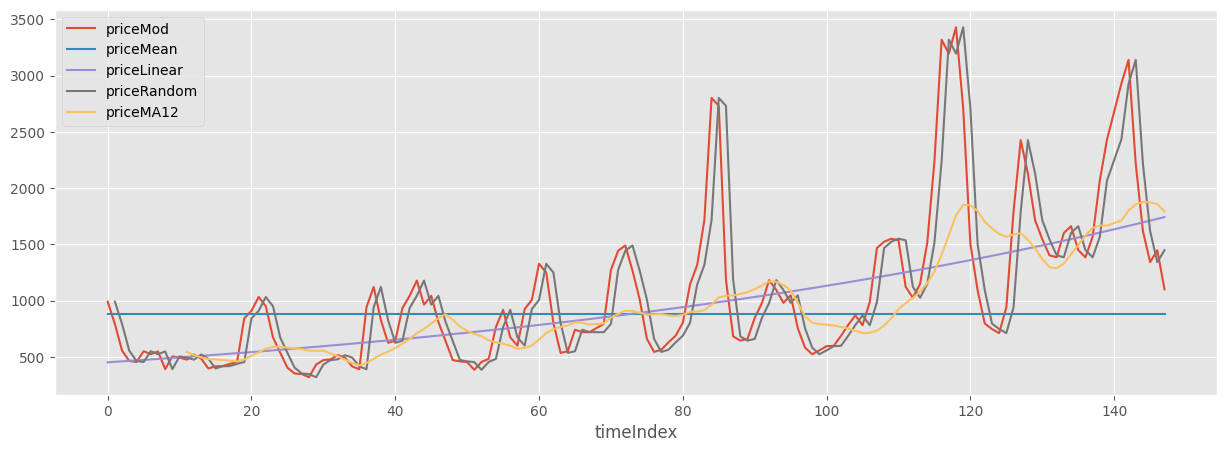

In [52]:
dfBang.plot(kind="line", x="timeIndex", y = ["priceMod", "priceMean", "priceLinear",
                                             "priceRandom", "priceMA12"]);

En ambos casos, podemos rechazar la hipótesis nula y, por lo tanto, considerar la serie como estacionaria.

## 3.b.ii) Modelo ARIMA

El modelo ARIMA sin estacionalidad surge por la combinación de:
* un modelo Auto-Regresivo (AR, p), basado en la diferenciación o rezago de la serie y
* un modelo de media móvil (MA por moving average, q).

Su denominación es producto de las siglas en inglés: **AutoRegressive Integrated Moving Average** model. "Integrated" (integrado) en este contexto refiere a revertir la diferenciación que mencionamos anteriormente. Veamos un mayor detalle de los dos modelos que componen ARIMA:

### Modelos Auto-Regresivos - AR (p)
En un modelo de autorregresión, pronosticamos la variable de interés usando una combinación lineal de valores pasados de la variable en cuestión. El término autoregresión indica que es una regresión de la variable contra sí misma. Por lo tanto, un modelo de **orden autorregresivo (p)** se puede escribir como:

$$ y_t = c + m_1y_ {t-1} + m_2y_ {t-2} + m_3y_ {t-3} + .. \\ $$
El Random Walk es un modelo AR (1) con $$ m_1 = 1,  c = 0 \\ $$ El Random Walk with drift (derivada) $$ m_1 = 1,  c \ != 0 \\ $$

Normalmente restringimos los modelos autorregresivos a datos estacionarios, también pueden ser necesarias algunas condiciones sobre los valores de los parámetros. Para un modelo AR (1): -1.

### Modelo de media móvil - MA (q)
En lugar de utilizar valores pasados de la variable a pronosticar mediante una regresión, un modelo de media móvil usa errores de pronóstico anteriores en un modelo similar a una regresión.

$$ y_t = c + e_t + l_1 e_ {t-1} + l_2 e_ {t-2} + ... + l_q e_ {t-q} \\ $$
donde e es ruido blanco. Nos referimos a esto como un modelo MA **(q)**, donde q representa la **cantidad de rezagos** considerados en el modelo. Por supuesto, no observamos los valores de e (t), por lo que no es realmente regresión en el sentido habitual.

Veamos que cada valor de y (t) se puede considerar como una media móvil ponderada de los últimos errores de pronóstico. Sin embargo, los modelos basados en la media móvil no deben confundirse con el suavizado del promedio móvil. Se usa un modelo de promedio móvil para pronosticar valores futuros, mientras que el suavizado promedio móvil se usa para estimar el ciclo de tendencia de valores pasados.

### Modelo ARIMA

El modelo completo se puede escribir como:
* **Número de términos AR (autorregresivos) (p)**: los términos AR son solo rezagos de la variable dependiente. Por ejemplo, si p es 5, los predictores para y (t) serán y (t-1) ... .y (t-5).
* **Número de términos MA (promedio móvil) (q)**: los términos MA son errores de pronóstico rezagados en la ecuación de predicción. Por ejemplo, si q es 5, los predictores para y (t) serán e (t-1) ... .e (t-5) donde e (i) es la diferencia entre el promedio móvil en el valor instantáneo y real.
* **Número de diferencias (d)**: son las diferencias no estacionales que necesitamos para la estacionariedad, es decir, en este caso tomamos la diferencia de primer orden. Entonces, o podemos pasar esa variable y poner d = 0 o pasar la variable original y poner d = 1. Ambos generarán los mismos resultados.

Una preocupación importante aquí es cómo determinar el valor de 'p' y 'q'. Usamos dos vías para determinar estos parámetros, veamos:

* **Función de autocorrelación (ACF)**: es una medida de la correlación entre la serie y su rezago, también se conoce como la función de autocorrelación total. Por ejemplo, en el desfasaje 5, ACF compararía series en el instante instante 't1' ... 't2' con series en el instante 't1-5' ... 't2-5', donde t1-5 y t2 puntos finales).
* **Función de autocorrelación parcial (PACF)**: mide la correlación entre la serie y su rezago después de eliminar las variaciones ya explicadas por las comparaciones intermedias. Por ejemplo, en el desfasaje 5, comprueba la correlación tras eliminar los efectos ya explicados por los rezagos 1 a 4.

En el modelo MA, el ruido (shock) se desvanece rápidamente con el tiempo. En sentido opuesto, el modelo AR tiene un efecto muy duradero del shock. De ahí que, mientras el primero se enfoca en períodos cortos de tiempo, el segundo prioriza el más largo plazo.

### **ACF (Autocorrelation Function)**:
- **¿Qué mide?** La ACF mide **cuánto se parecen** los valores de una serie temporal con sus propios valores en el pasado.
- **¿Cómo se usa?** Si tienes una serie de datos (por ejemplo, precios de acciones), la ACF te dice si el precio de hoy está relacionado con el precio de ayer, o el de hace 3 días, o el de hace 10 días, y cuánto se parecen.
- **Ejemplo simple**: Si los precios de las acciones de ayer y de hace 3 días son similares, la ACF te muestra esa relación. Cuanto más largo es el "tiempo" entre los días, más débil es la relación.

### **PACF (Partial Autocorrelation Function)**:
- **¿Qué mide?** La PACF también mide las relaciones entre los valores de la serie en diferentes momentos, pero **eliminando el efecto de los momentos intermedios**.
- **¿Cómo se usa?** Imagina que quieres saber si el precio de hoy está relacionado con el de hace 5 días, pero **sin considerar lo que pasó entre esos días** (como el día 4 o el día 3). La PACF te ayuda a ver esa relación directa.
- **Ejemplo simple**: Si los precios de ayer y de hace 5 días están relacionados, la PACF te dice eso sin que se vean afectadas por los días intermedios (como el día 4).

### **¿Por qué son útiles?**
- **ACF**: Te ayuda a entender la relación general entre los datos a diferentes tiempos.
- **PACF**: Te da una idea más precisa de la relación directa, sin que influya lo que sucedió en los tiempos intermedios.

### **Resumen**:
En resumen, ACF te muestra la **relación general** entre los valores a través del tiempo, y PACF te muestra la **relación directa** sin interferencias de los valores intermedios. Ambos son útiles cuando construimos modelos para predecir valores futuros de una serie temporal (como el precio de las acciones o la temperatura).


In [53]:
ts = dfBang.priceModLog
ts_diff = dfBang.priceModLogDiff
ts_diff.dropna(inplace = True)

In [54]:
# Importamos plots ACF y PACF
from statsmodels.tsa.stattools import acf, pacf

### ¿Qué son los lags?

En el contexto de **series temporales**, un **lag** (o rezago en español) se refiere a la cantidad de tiempo o unidades de tiempo entre dos observaciones de la misma serie. Básicamente, un "lag" es una **desviación temporal** de una observación en el pasado respecto al momento actual.

### Ejemplo sencillo:
Si tienes una serie de datos que representa los precios de una acción durante varios días, los **lags** pueden ser:

- **Lag 1**: El precio de ayer.
- **Lag 2**: El precio de hace dos días.
- **Lag 3**: El precio de hace tres días, y así sucesivamente.

### ¿Por qué son importantes los lags?

Los **lags** son muy útiles en el análisis de series temporales porque ayudan a entender cómo los valores pasados pueden influir en los valores futuros. Por ejemplo, si se quiere predecir el precio de una acción, podría ser útil ver cómo se comportó en los días anteriores, es decir, cómo se relaciona el precio de hoy con el precio de ayer, hace dos días, etc.

### ¿Cómo se usan los lags?

- **En ACF (Autocorrelation Function)**: La ACF muestra las relaciones entre una observación y sus propias versiones desplazadas en el tiempo (lags). Por ejemplo, la correlación entre el valor de hoy y el valor de ayer sería el **lag 1**.
  
- **En modelos ARIMA**: El concepto de lag es fundamental. Los modelos AR (AutoRegresivos) utilizan **lags** de la serie para predecir el valor futuro. Si se usan **lags 1, 2, y 3**, significa que el modelo está considerando el valor actual y los valores de los 3 días anteriores para hacer una predicción.

### Resumen:
- Un **lag** es simplemente un retraso temporal en los datos.
- Los lags se usan para ver la relación entre los datos actuales y pasados.
- Son esenciales en el análisis de series temporales para detectar patrones y realizar predicciones.


### ¿Cómo funciona el cálculo de la ACF con `lag_acf = acf(ts_diff, nlags=20)`?

1. **Serie Temporal (`ts_diff`)**:
   - La serie temporal que estás usando es `ts_diff`. Esta puede ser, por ejemplo, una serie de datos que representa las diferencias entre los valores originales de una serie (como si hicieras una "diferenciación" para hacerla más estacionaria).
   
2. **Lags**:
   - El parámetro `nlags=20` significa que se calculan las autocorrelaciones entre el valor **actual** de la serie y sus **valores anteriores** hasta un máximo de 20 períodos (lags).
   
### ¿Qué pasa con el "valor actual"?

En el caso de la **autocorrelación**:
- El **valor actual** de la serie es el valor de la serie en el tiempo más reciente (por ejemplo, el valor en el día actual, el último registro de la serie).
- Luego, para cada **lag** (rezago), se calcula la **correlación** entre el valor actual de la serie y el valor de la serie en el pasado, desplazado por un cierto número de períodos (lags).

### Ejemplo práctico:

Imagina que tienes una serie temporal de precios de una acción, y la serie de precios es algo así:

| Día | Precio |
|-----|--------|
| 1   | 100    |
| 2   | 102    |
| 3   | 105    |
| 4   | 107    |
| 5   | 110    |

#### Ahora, ¿cómo se calcula la autocorrelación?

Supongamos que `ts_diff` es una serie diferenciada (es decir, restaste cada valor con el valor anterior), y estás calculando la ACF con `nlags=3`.

- **Lag 0**: Es la correlación del **valor actual con él mismo**, por lo que la autocorrelación para lag 0 es siempre 1 (perfecta correlación).
  
- **Lag 1**: Es la **correlación entre el valor actual y el valor del período anterior**. Esto quiere decir que se calculará la relación entre el valor de la serie en el **día 5** (110) y el valor de la serie en el **día 4** (107).
  
- **Lag 2**: Es la **correlación entre el valor actual y el valor de hace 2 períodos**. Es decir, se calcula la relación entre el valor en el **día 5** (110) y el valor en el **día 3** (105).

- **Lag 3**: Es la **correlación entre el valor actual y el valor de hace 3 períodos**. Aquí se calcula la relación entre el valor en el **día 5** (110) y el valor en el **día 2** (102).

Y así sucesivamente hasta el **lag 20**.

### ¿Qué contiene el resultado?

El resultado de `lag_acf` es una lista de valores que representan la **autocorrelación** entre la serie temporal actual y los valores anteriores, para cada uno de los **20 primeros lags**.

Ejemplo de resultados posibles:



In [55]:
lag_acf = acf(ts_diff, nlags=20)
lag_acf

array([ 1.        ,  0.40215445, -0.02855346, -0.21472715, -0.23756032,
       -0.26332645, -0.22038359, -0.08576989, -0.0754398 ,  0.01497797,
        0.12361818,  0.20862956,  0.158123  ,  0.02053933, -0.01290934,
       -0.07097602, -0.17993659, -0.09514604, -0.04878255, -0.08854117,
       -0.18810881])

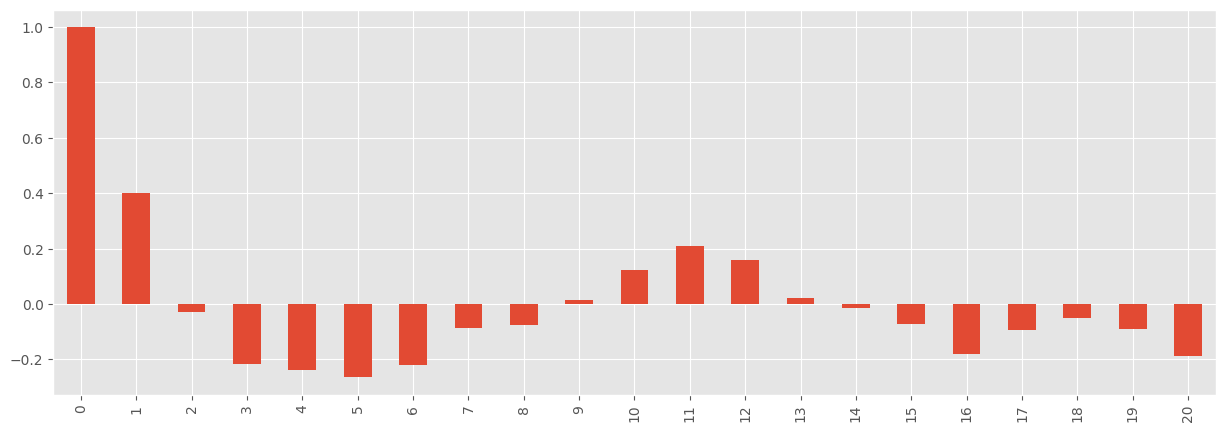

In [56]:
ACF = pd.Series(lag_acf)
ACF.plot(kind = "bar");

In [60]:
lag_pacf = pacf(ts_diff, nlags=20, method='ols');
lag_pacf

array([ 1.        ,  0.40559554, -0.23017027, -0.13516088, -0.11478398,
       -0.20975942, -0.15227425, -0.07222987, -0.22959306, -0.05680816,
       -0.0292726 ,  0.02726083, -0.02890427, -0.08707528,  0.02247884,
       -0.05438726, -0.16367752,  0.06843976, -0.12021411, -0.16676323,
       -0.30020573])

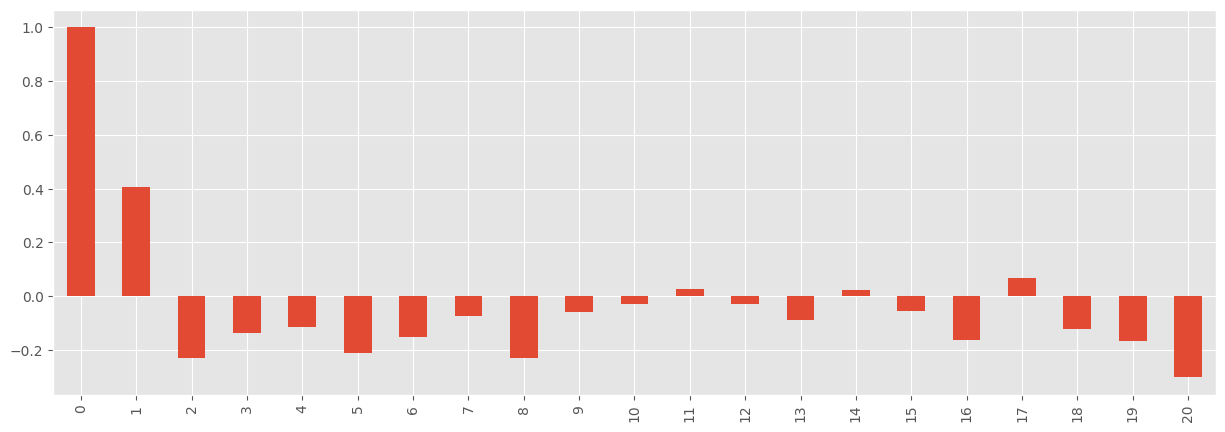

In [58]:
PACF = pd.Series(lag_pacf)
PACF.plot(kind = "bar");

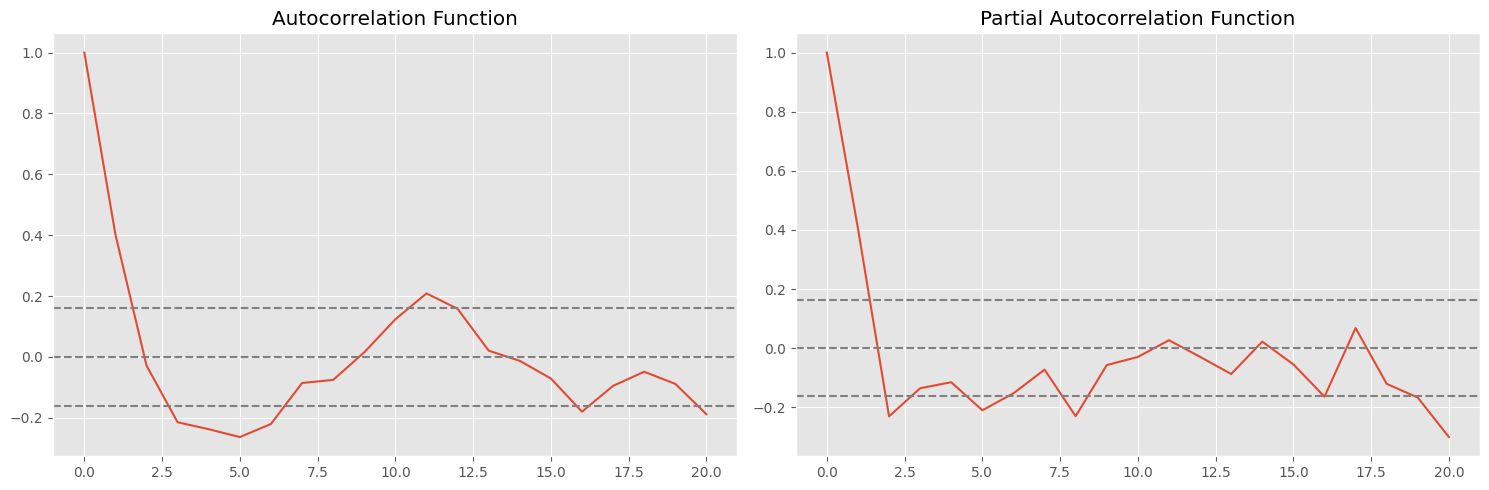

In [59]:
# Veamos qué parámetros son significativamente distintos de cero

#Plot ACF:
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts)),linestyle='--',color='gray')
plt.title('Autocorrelation Function')

#Plot PACF:
plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts)),linestyle='--',color='gray')
plt.title('Partial Autocorrelation Function')
plt.tight_layout()

En el modelo de autocorrelación parcial el primer order es estadísticamente significativo y en los períodos siguientes el shock se licúa y los parámetros son cercanos a 0. Es por esto que vamos a elegir un modelo AR(1) y MA(1).

Dicho de otra forma, según dónde se den los cortes bruscos en ACF y PACF, son los valores que elegiremos para AR y MA.

Un corte brusco en la ACF o PACF ocurre cuando los coeficientes de autocorrelación caen abruptamente a valores cercanos a cero después de un cierto número de rezagos.

Por ejemplo, veamos nuestro array de ACF y PACF calculado:

In [62]:
lag_acf

array([ 1.        ,  0.40215445, -0.02855346, -0.21472715, -0.23756032,
       -0.26332645, -0.22038359, -0.08576989, -0.0754398 ,  0.01497797,
        0.12361818,  0.20862956,  0.158123  ,  0.02053933, -0.01290934,
       -0.07097602, -0.17993659, -0.09514604, -0.04878255, -0.08854117,
       -0.18810881])

In [63]:
lag_pacf

array([ 1.        ,  0.40559554, -0.23017027, -0.13516088, -0.11478398,
       -0.20975942, -0.15227425, -0.07222987, -0.22959306, -0.05680816,
       -0.0292726 ,  0.02726083, -0.02890427, -0.08707528,  0.02247884,
       -0.05438726, -0.16367752,  0.06843976, -0.12021411, -0.16676323,
       -0.30020573])

En el primero, vemos que entre el primer valor (1) y el segundo (0.40...) se da una caída abrupta, es decir, un corte brusco. Entonces, como ACF nos sirve para determinar $q$ de MA, podemos decir que en el primer lag (posición) termina la estabilidad y después de ahí decrece abruptamente, entonces tenemos MA(1).

Algo similar ocurre con el segundo caso con PACF, y como PACF nos sirve para determinar $p$, tenemos por casualidad en este caso AR(1).

# ¿Qué es un Corte Brusco en ACF y PACF?

Un **corte brusco** en la ACF o PACF ocurre cuando los coeficientes de autocorrelación caen abruptamente a valores cercanos a **cero** después de un cierto número de rezagos.

## 📌 Ejemplo visual de un corte brusco en PACF y ACF

### 🔹 Corte brusco en PACF en rezago $p = 2$  


Rezago   | PACF
---------|-------
1        | 0.6
2        | 0.4
3        | 0.05  ← 📉 Corte brusco aquí
4        | 0.02
5        | -0.01

Aquí, la **PACF** muestra valores significativos hasta el rezago **2**, pero luego los valores se acercan a cero.  
➡️ **Esto sugiere un modelo AR(2).**

---

### 🔹 Corte brusco en ACF en rezago $q = 1$  

Rezago   | ACF
---------|-------
1        | 0.7
2        | 0.1  ← 📉 Corte brusco aquí
3        | 0.02
4        | -0.01


Aquí, la **ACF** muestra un valor alto en **rezago 1**, pero cae abruptamente después.  
➡️ **Esto sugiere un modelo MA(1).**

---

## 🎯 ¿Cómo distinguir un corte brusco?

✔ **Corte brusco** → La serie muestra **valores altos** en los primeros rezagos y luego cae abruptamente a valores cercanos a **cero**.  
❌ **Decrecimiento gradual** → La serie **no cae abruptamente**, sino que disminuye poco a poco en los rezagos siguientes.

---

## 🔎 Regla práctica para ARIMA
- Si la **PACF tiene un corte brusco** en el rezago $p$, usa un modelo **AR($p$)**.
- Si la **ACF tiene un corte brusco** en el rezago $q$, usa un modelo **MA($q$)**.
- Si **ninguna tiene un corte claro**, prueba un modelo **ARMA($p, q$)**.

🚀 Con esto puedes interpretar **ACF y PACF** para ajustar un modelo **ARIMA** correctamente.


### Modelando con ARIMA

In [64]:
from statsmodels.tsa.arima.model import ARIMA
ts.head()

,priceModLog
date,
2004-01,6.898715
2004-02,6.675823
2004-03,6.320768
2004-04,6.142037
2004-05,6.120297


In [65]:
# Instancio el modelo con parámetros (p=1,d=0,q=1) según el análisis de ACF y PACF
# En este caso d=0 porque trabajamos directamente con las diferencias
model_AR1MA = ARIMA(ts_diff, order=(1,0,1))

# Fiteo el modelo
results_ARIMA = model_AR1MA.fit()
results_ARIMA.fittedvalues.head()

,0
date,
2004-02,-0.000983
2004-03,-0.093810
2004-04,-0.139363
2004-05,-0.041734
2004-06,0.002160


In [66]:
print(results_ARIMA.summary())

                               SARIMAX Results                                
Dep. Variable:        priceModLogDiff   No. Observations:                  145
Model:                 ARIMA(1, 0, 1)   Log Likelihood                  12.361
Date:                Fri, 28 Feb 2025   AIC                            -16.721
Time:                        18:03:48   BIC                             -4.814
Sample:                    02-29-2004   HQIC                           -11.883
                         - 02-29-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0010      0.030     -0.032      0.974      -0.061       0.059
ar.L1          0.1582      0.217      0.730      0.466      -0.267       0.583
ma.L1          0.3215      0.186      1.733      0.0

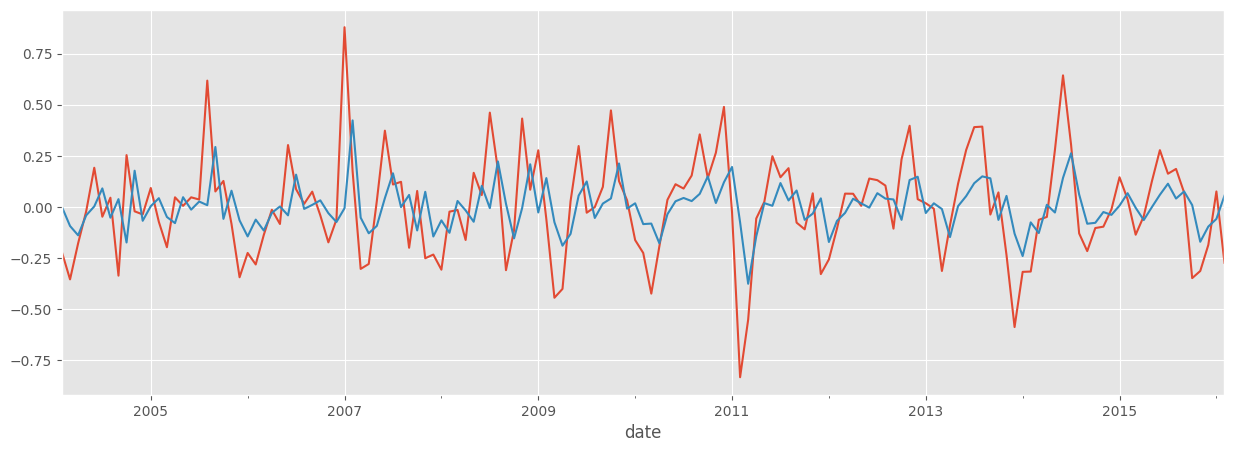

In [67]:
ts_diff.plot()
results_ARIMA.fittedvalues.plot();

In [68]:
ts_diff.sum()

0.1052596023926915

In [69]:
predictions_ARIMA_diff = pd.Series(results_ARIMA.fittedvalues, copy=True)
predictions_ARIMA_diff.tail()

,0
date,
2015-10,0.008534
2015-11,-0.170976
2015-12,-0.096514
2016-01,-0.059159
2016-02,0.054304


In [70]:
predictions_ARIMA_diff_cumsum = predictions_ARIMA_diff.cumsum()
predictions_ARIMA_diff_cumsum.tail()

,0
date,
2015-10,0.343822
2015-11,0.172846
2015-12,0.076332
2016-01,0.017173
2016-02,0.071477


In [71]:
ts.iloc[0]

6.898714534329988

In [72]:
predictions_ARIMA_log = pd.Series(ts.iloc[0], index=ts.index)
predictions_ARIMA_log = predictions_ARIMA_log.add(predictions_ARIMA_diff_cumsum,fill_value=0)
predictions_ARIMA_log.tail()

,0
date,
2015-10,7.242536
2015-11,7.071561
2015-12,6.975047
2016-01,6.915887
2016-02,6.970191


In [73]:
# Guardamos nuestros resultados
dfBang['priceARIMA'] = np.exp(predictions_ARIMA_log)

In [74]:
# Incorporamos estimaciones y resultados a nuestro DF
dfBangResults.loc[5,"Model"] = "ARIMA"
dfBangResults.loc[5,"Forecast"] = dfBang.priceARIMA[-1]
dfBangResults.loc[5,"RMSE"] = RMSE(dfBang.priceARIMA, dfBang.priceMod)

<ipython-input-74-d6480fcd71e9>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dfBangResults.loc[5,"Forecast"] = dfBang.priceARIMA[-1]


In [75]:
dfBangResults.head(10)

,Model,Forecast,RMSE
0,Mean,884.565812,683.953348
1,Linear,"[452.39310614946214, 456.5630144738825, 460.77...",518.358229
2,LinearQuantity,2264.30834,505.131419
3,Random,1448.0,323.5924
4,Moving Average 12,1794.694278,518.821751
5,ARIMA,1064.426332,517.748047


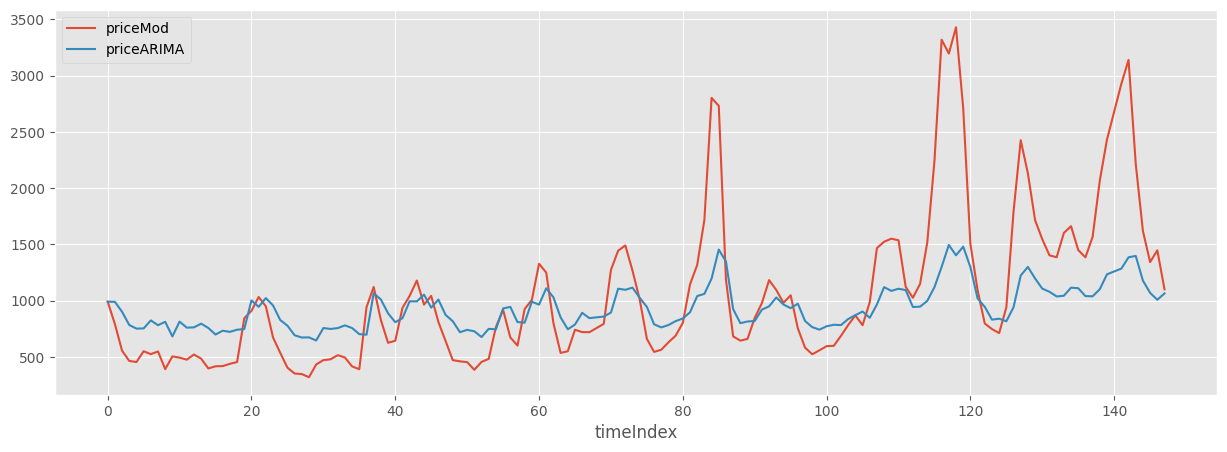

In [76]:
dfBang.plot(kind="line", x="timeIndex", y = ["priceMod", "priceARIMA"]);

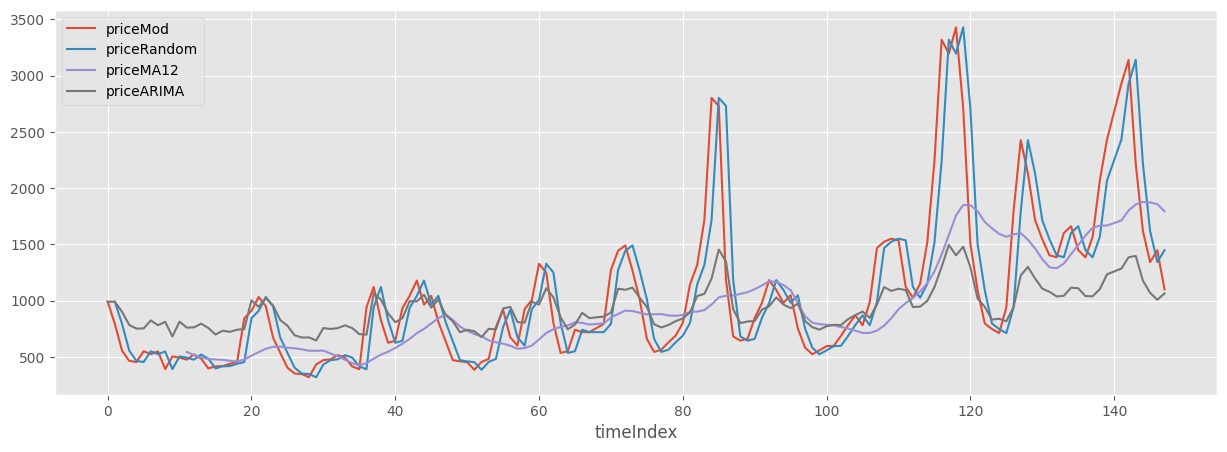

In [77]:
dfBang.plot(kind="line", x="timeIndex", y = ["priceMod", "priceRandom",
                                             "priceMA12", "priceARIMA"]);

* ¿Qué modelo performa mejor? ¿Elegirías alguno? ¿Por qué?